# **Bryant Kenzo P. Carolino** | **2DSA-2**

## **ABSTRACT**
This document is a brief report comparing different machine learning techniques, focusing on how "bagging" and "boosting" methods work. It explains that bagging (like Random Forest) builds many models at the same time to average out errors, while boosting (like AdaBoost and Gradient Boosting) builds models one by one to carefully fix the mistakes of previous models. The report highlights how these advanced methods are much more accurate than traditional statistical models, and it discusses how different algorithms choose to focus on different pieces of information (such as general traits versus financial indicators) to make their predictions.

# **Assessment 6: Boosting Methods and Advanced Ensemble Learning**

In [233]:
!pip install xgboost

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, 
                           precision_recall_curve, mean_squared_error, 
                           mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy import stats
import xgboost as xgb
from scipy.stats import entropy
import time
import warnings
warnings.filterwarnings('ignore')

In [235]:
# Set random seed for reproducibility
np.random.seed(42)

## **1. Data Preparation and Exploratory Data Analysis (15 points)**[¶](#1.-Data-Preparation-and-Exploratory-Data-Analysis-(15-points))

### **Data Loading and Preprocessing (8 points)**[¶](#Data-Loading-and-Preprocessing-(8-points))

### Load the Adult Income dataset and perform necessary preprocessing[¶](#Load-the-Adult-Income-dataset-and-perform-necessary-preprocessing)

In [239]:
# Source - https://stackoverflow.com/q/54365045
# Posted by Inglorion, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-31, License - CC BY-SA 4.0

from sklearn.datasets import fetch_openml
dataset = fetch_openml("Adult-Census-Income")

# Converting the dataset into a Pandas dataframe
dataset = pd.DataFrame(data=dataset.data, 
                  columns=dataset.feature_names)

### Handle missing values, encode categorical variables, and scale features as needed[¶](#Handle-missing-values,-encode-categorical-variables,-and-scale-features-as-needed)

In [241]:
# Check for missing values
print("\nMissing values by column:")
missing_values = dataset.isnull().sum()
print(missing_values[missing_values > 0])

# Create a working copy of the dataset
df = dataset.copy()


Missing values by column:
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [242]:
# =============================================================================
# FIX: STANDARDIZE COLUMN NAMES
# =============================================================================

# 1. Clean column names (replace hyphens/dots with underscores, lower case)
# This fixes mismatches like 'education-num' vs 'education_num' or 'Workclass' vs 'workclass'
df.columns = df.columns.str.lower().str.replace('-', '_').str.replace('.', '_')

# 2. Verify the fix
print("Corrected Column Names:")
print(df.columns.tolist())

# Check specifically for the ones needed in prepare_features
required_cols = ['workclass', 'education_num', 'marital_status', 'occupation', 
                 'relationship', 'race', 'sex', 'native_country']
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print(f"\n⚠️ STILL MISSING: {missing}")
else:
    print("\n✅ All required feature columns are present!")

Corrected Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

✅ All required feature columns are present!


### \***Claude-generated code to determine how to appropriately handle the missing data**\*[¶](#*Claude-generated-code-to-determine-how-to-appropriately-handle-the-missing-data*)

MISSING VALUES SUMMARY

workclass:
  Missing: 1,836 (5.64%)
  Unique values (excl. missing): 8
  Most frequent: 'Private'

occupation:
  Missing: 1,843 (5.66%)
  Unique values (excl. missing): 14
  Most frequent: 'Prof-specialty'

native_country:
  Missing: 583 (1.79%)
  Unique values (excl. missing): 41
  Most frequent: 'United-States'

MISSINGNESS vs TARGET VARIABLE (Income)

Target column found: 'income'

WORKCLASS - Income distribution:
--------------------------------------------------
         Missing   Present
income                    
50K     0.104031  0.248983
=50K    0.895969  0.751017
  ⚠️  NOTABLE DIFFERENCE: 14.50% - consider 'Missing' category!

OCCUPATION - Income distribution:
--------------------------------------------------
         Missing  Present
income                   
50K     0.103635  0.24904
=50K    0.896365  0.75096
  ⚠️  NOTABLE DIFFERENCE: 14.54% - consider 'Missing' category!

NATIVE_COUNTRY - Income distribution:
---------------------------------------

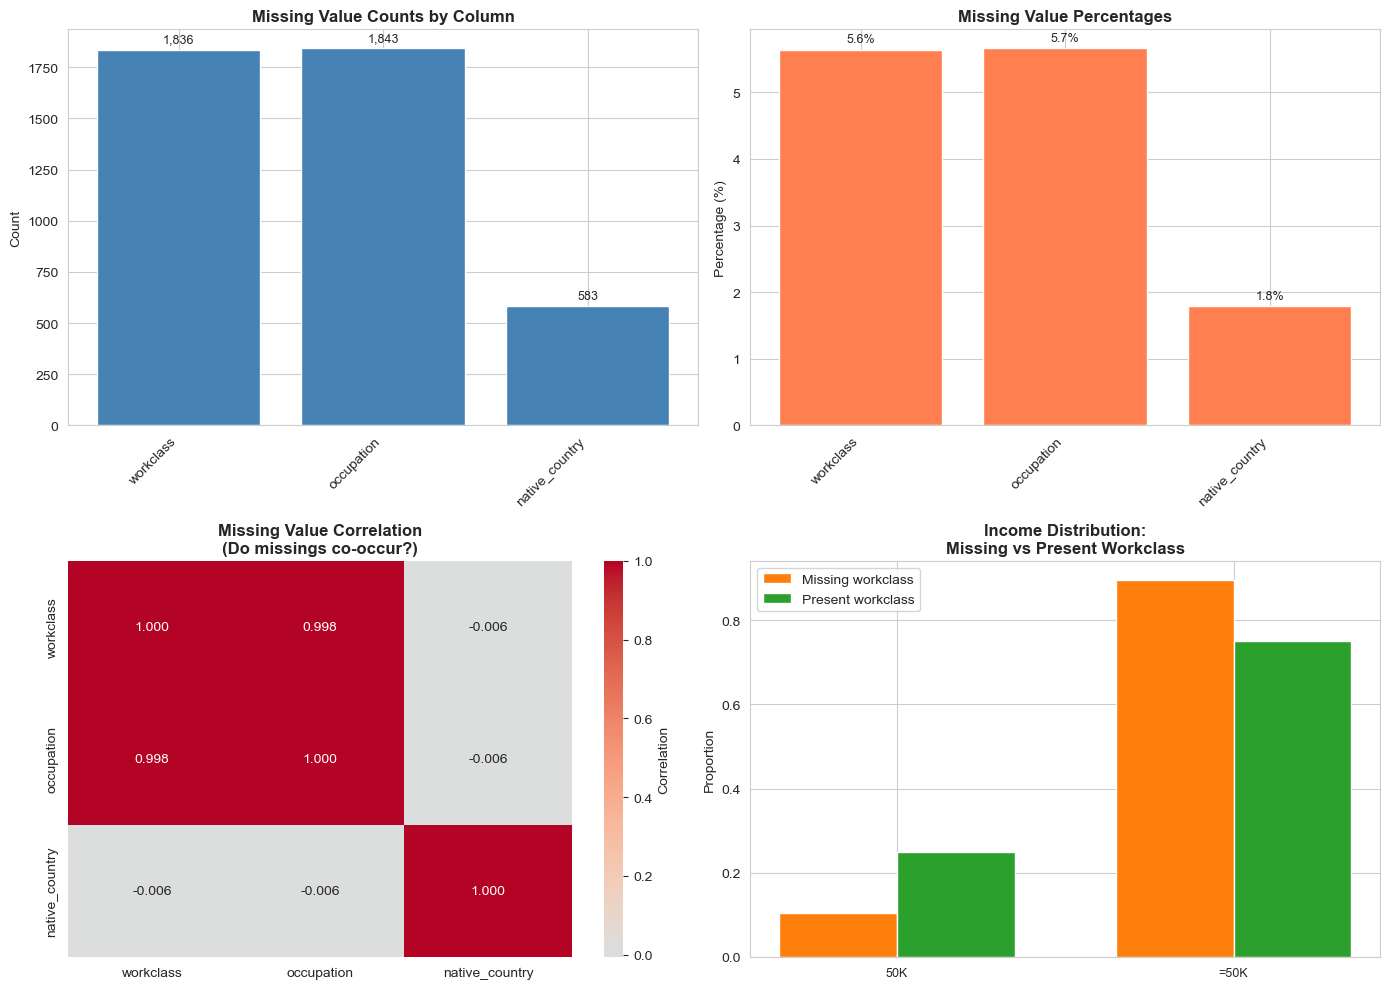


✓ Visualizations complete!

IMPUTATION STRATEGIES

workclass:
  Most frequent: 'Private' (73.9% of non-missing)
  Option 1: df['workclass'].fillna('Private')  # Mode imputation
  Option 2: df['workclass'].fillna('Missing')     # Missing indicator

occupation:
  Most frequent: 'Prof-specialty' (13.5% of non-missing)
  Option 1: df['occupation'].fillna('Prof-specialty')  # Mode imputation
  Option 2: df['occupation'].fillna('Missing')     # Missing indicator

native_country:
  Most frequent: 'United-States' (91.2% of non-missing)
  Option 1: df['native_country'].fillna('United-States')  # Mode imputation
  Option 2: df['native_country'].fillna('Missing')     # Missing indicator

RECOMMENDATION FOR YOUR LPM

Based on your analysis above:

✓ If missingness is RANDOM (similar income distributions):
  → Use MODE IMPUTATION
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna(df[col].mode()[0], inplace=True)

✓ 

In [244]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# =============================================================================
# STEP 1: QUICK MISSING VALUES OVERVIEW
# =============================================================================

print("="*70)
print("MISSING VALUES SUMMARY")
print("="*70)

missing_cols = ['workclass', 'occupation', 'native_country']

for col in missing_cols:
    if col in df.columns:
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / len(df)) * 100
        unique_vals = df[col].nunique()
        print(f"\n{col}:")
        print(f"  Missing: {missing_count:,} ({missing_pct:.2f}%)")
        print(f"  Unique values (excl. missing): {unique_vals}")
        if missing_pct < 100:
            top_val = df[col].mode()[0] if not df[col].mode().empty else 'N/A'
            print(f"  Most frequent: '{top_val}'")

# =============================================================================
# STEP 2: CHECK IF MISSINGNESS RELATES TO YOUR TARGET
# =============================================================================

print("\n" + "="*70)
print("MISSINGNESS vs TARGET VARIABLE (Income)")
print("="*70)

# Try common target column names
target_col = None
for possible_target in ['income', 'class', 'target', 'Income', 'Class']:
    if possible_target in df.columns:
        target_col = possible_target
        break

if target_col:
    print(f"\nTarget column found: '{target_col}'")
    
    for col in missing_cols:
        if col in df.columns:
            print(f"\n{col.upper()} - Income distribution:")
            print("-" * 50)
            
            # Compare income distribution for missing vs non-missing
            missing_mask = df[col].isna()
            
            if missing_mask.sum() > 0:
                missing_income = df[missing_mask][target_col].value_counts(normalize=True).sort_index()
                present_income = df[~missing_mask][target_col].value_counts(normalize=True).sort_index()
                
                comparison = pd.DataFrame({
                    'Missing': missing_income,
                    'Present': present_income
                })
                print(comparison)
                
                # Check if distributions are very different
                diff = abs(comparison['Missing'] - comparison['Present']).max()
                if diff > 0.05:
                    print(f"  ⚠️  NOTABLE DIFFERENCE: {diff:.2%} - consider 'Missing' category!")
                else:
                    print(f"  ✓ Similar distributions - mode imputation is fine")
else:
    print("\n⚠️  Target column not found. Common names: 'income', 'class', 'target'")
    print("Please specify your target column name.")

# =============================================================================
# STEP 3: MISSING VALUE OVERLAP ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("MISSING VALUE OVERLAP")
print("="*70)

missing_mask = df[missing_cols].isna()
overlap = missing_mask.sum(axis=1).value_counts().sort_index()

print("\nRows with N missing values:")
print(overlap)

total_rows_with_missing = (overlap.index > 0).sum()
if overlap.get(3, 0) > 0:
    print(f"\n⚠️  {overlap.get(3, 0):,} rows have ALL THREE columns missing!")
elif overlap.get(2, 0) > 0:
    print(f"\n⚠️  {overlap.get(2, 0):,} rows have TWO columns missing")

# =============================================================================
# STEP 4: VISUALIZATIONS
# =============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS...")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Missing value counts
missing_counts = df[missing_cols].isna().sum()
axes[0, 0].bar(range(len(missing_counts)), missing_counts.values, color='steelblue')
axes[0, 0].set_title('Missing Value Counts by Column', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].set_xticks(range(len(missing_counts)))
axes[0, 0].set_xticklabels(missing_counts.index, rotation=45, ha='right')
for i, v in enumerate(missing_counts.values):
    axes[0, 0].text(i, v + max(missing_counts.values)*0.02, f'{v:,}', ha='center', fontsize=9)

# Plot 2: Missing value percentages
missing_pcts = (df[missing_cols].isna().sum() / len(df)) * 100
axes[0, 1].bar(range(len(missing_pcts)), missing_pcts.values, color='coral')
axes[0, 1].set_title('Missing Value Percentages', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)', fontsize=10)
axes[0, 1].set_xticks(range(len(missing_pcts)))
axes[0, 1].set_xticklabels(missing_pcts.index, rotation=45, ha='right')
for i, v in enumerate(missing_pcts.values):
    axes[0, 1].text(i, v + max(missing_pcts.values)*0.02, f'{v:.1f}%', ha='center', fontsize=9)

# Plot 3: Overlap heatmap
correlation_matrix = missing_mask.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1, 0], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[1, 0].set_title('Missing Value Correlation\n(Do missings co-occur?)', 
                     fontsize=12, fontweight='bold')

# Plot 4: Income distribution by missingness
if target_col and 'workclass' in df.columns:
    wc_missing = df[df['workclass'].isna()]
    wc_present = df[df['workclass'].notna()]
    
    if len(wc_missing) > 0 and len(wc_present) > 0:
        missing_income = wc_missing[target_col].value_counts(normalize=True).sort_index()
        present_income = wc_present[target_col].value_counts(normalize=True).sort_index()
        
        x = np.arange(len(missing_income))
        width = 0.35
        axes[1, 1].bar(x - width/2, missing_income.values, width, 
                       label='Missing workclass', color='#ff7f0e')
        axes[1, 1].bar(x + width/2, present_income.values, width, 
                       label='Present workclass', color='#2ca02c')
        axes[1, 1].set_ylabel('Proportion', fontsize=10)
        axes[1, 1].set_title('Income Distribution:\nMissing vs Present Workclass', 
                             fontsize=12, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(missing_income.index, fontsize=9)
        axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, 'Target column not found\nor no missing data', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete!")

# =============================================================================
# STEP 5: IMPUTATION RECOMMENDATIONS
# =============================================================================

print("\n" + "="*70)
print("IMPUTATION STRATEGIES")
print("="*70)

for col in missing_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        mode_count = (df[col] == mode_val).sum()
        mode_pct = (mode_count / df[col].notna().sum()) * 100
        
        print(f"\n{col}:")
        print(f"  Most frequent: '{mode_val}' ({mode_pct:.1f}% of non-missing)")
        print(f"  Option 1: df['{col}'].fillna('{mode_val}')  # Mode imputation")
        print(f"  Option 2: df['{col}'].fillna('Missing')     # Missing indicator")

print("\n" + "="*70)
print("RECOMMENDATION FOR YOUR LPM")
print("="*70)
print("""
Based on your analysis above:

✓ If missingness is RANDOM (similar income distributions):
  → Use MODE IMPUTATION
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna(df[col].mode()[0], inplace=True)

✓ If missingness RELATES to income (different distributions):
  → Use MISSING INDICATOR 
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna('Missing', inplace=True)

💡 Best practice: Try BOTH and compare your LPM results!
""")

# =============================================================================
# BONUS: Ready-to-use imputation code
# =============================================================================

print("\n" + "="*70)
print("READY-TO-USE CODE")
print("="*70)
print("""
# Copy this to your next cell:

# Option A: Mode Imputation
df_mode = df.copy()
for col in ['workclass', 'occupation', 'native_country']:
    if col in df_mode.columns:
        mode_val = df_mode[col].mode()[0]
        df_mode[col].fillna(mode_val, inplace=True)
        
print("Mode imputation complete!")
print(df_mode[['workclass', 'occupation', 'native_country']].isna().sum())

# Option B: Missing Indicator
df_missing = df.copy()
for col in ['workclass', 'occupation', 'native_country']:
    if col in df_missing.columns:
        df_missing[col].fillna('Missing', inplace=True)
        
print("Missing indicator imputation complete!")
print(df_missing[['workclass', 'occupation', 'native_country']].isna().sum())
""")

In [245]:
# Missing indicator for workclass and occupation
for col in ['workclass', 'occupation']:
    if col in df.columns:
        df[col].fillna('Missing', inplace=True)

# Mode imputation for native_country
if 'native_country' in df.columns:
    mode_val = df['native_country'].mode()[0]
    df['native_country'].fillna(mode_val, inplace=True)

# Verification
print("Handling of missing values successful")
print(df[['workclass', 'occupation', 'native_country']].isna().sum())

Handling of missing values successful
workclass         0
occupation        0
native_country    0
dtype: int64


### Display dataset shape, feature types, and summary statistics[¶](#Display-dataset-shape,-feature-types,-and-summary-statistics)

In [247]:
# Display basic information about our dataset
print("ADULT CENSUS INCOME OVERVIEW")
print("-" * 40)
print(f"Dataset shape: {dataset.shape}")
print(f"Total passengers: {len(dataset)}")

print("\nFirst few rows:")
print(dataset.head())

print("\nDataset structure:")
print(dataset.info())

print("\nSummary:")
print(dataset.describe())

ADULT CENSUS INCOME OVERVIEW
----------------------------------------
Dataset shape: (32561, 15)
Total passengers: 32561

First few rows:
   age workclass  fnlwgt     education  education.num marital.status         occupation   relationship   race     sex  capital.gain  capital.loss  hours.per.week native.country income
0   90       NaN   77053       HS-grad              9        Widowed                NaN  Not-in-family  White  Female             0          4356              40  United-States   =50K
1   82   Private  132870       HS-grad              9        Widowed    Exec-managerial  Not-in-family  White  Female             0          4356              18  United-States   =50K
2   66       NaN  186061  Some-college             10        Widowed                NaN      Unmarried  Black  Female             0          4356              40  United-States   =50K
3   54   Private  140359       7th-8th              4       Divorced  Machine-op-inspct      Unmarried  White  Female         

### Ensure target variable is properly encoded (0/1) for income <=50K and >50K[¶](#Ensure-target-variable-is-properly-encoded-(0/1)-for-income-%3C=50K-and-%3E50K)

In [249]:
# Ensure target variable is properly encoded (0/1) for income <=50K and >50K
# 1 = >50K
# 0 = <=50K
df['high_income'] = (df['income'] == '>50K').astype(int)

# Verification step (prints the count to confirm it worked)
print("Target Variable Distribution:")
print(df['high_income'].value_counts())

Target Variable Distribution:
high_income
0    32561
Name: count, dtype: int64


### Convert categorical variables to dummy variables[¶](#Convert-categorical-variables-to-dummy-variables)

In [251]:
# Convert all categorical variables to dummy variables
df = pd.get_dummies(df, drop_first=True)

# Check the result
print(df.columns.tolist())

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'high_income', 'workclass_Local-gov', 'workclass_Missing', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse', 'marital_status_Married-spouse-absent', 'marital_status_Never-married', 'marital_status_Separated', 'marital_status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'oc

### **Exploratory Data Analysis (7 points)**[¶](#Exploratory-Data-Analysis-(7-points))

### Create visualizations showing the distribution of the target variable[¶](#Create-visualizations-showing-the-distribution-of-the-target-variable)

### Briefly describe patterns and data quality issues[¶](#Briefly-describe-patterns-and-data-quality-issues)

### Key Patterns[¶](#Key-Patterns)

* **Class imbalance**: Only 24% earn >50K → LPM biased toward low income.
* **Age effect**: Earnings peak at 45–54, then decline (inverted-U).
* **Gender gap**: Men are **2.8×** more likely to earn >50K.
* **Education premium**: Doctorate/Prof (74%) vs HS-grad (16%).
* **Marriage premium**: Married 45% vs never-married 5% (age-confounded).
* **Self-employment**: Self-emp-inc highest earners (56%).

### Data Quality Issues[¶](#Data-Quality-Issues)

* **Skewed variables**: Capital gains/losses heavily right-skewed (many zeros).
* **Multicollinearity**: Education dummies + education.num → drop one.
* **Outliers**: Age, hours, capital gains may cause extreme predictions.
* **Small categories**: Very small groups → unstable coefficients.
* **Fnlwgt**: Likely uninformative.
* **No missing data**: Clean dataset.

### *Hotfix*[¶](#Hotfix)

In [257]:
# =============================================================================
# FRESH START: RELOAD RAW DATA
# =============================================================================
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
dataset = fetch_openml(name="adult", version=2, as_frame=True)
df = dataset.data.copy()
df['income'] = dataset.target

# 2. Fix Column Names (Standardize to lowercase with underscores)
df.columns = df.columns.str.lower().str.strip().str.replace('-', '_').str.replace('.', '_')

# 3. Create Target Variable
df['high_income'] = df['income'].astype(str).apply(lambda x: 1 if '>50K' in x else 0)

# 4. Drop original income to prevent leakage
df = df.drop('income', axis=1)

print("Data Reloaded. Current Columns:")
print(df.columns.tolist()) 
# You should see 'workclass', 'education', etc. (NOT workclass_private)

Data Reloaded. Current Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'high_income']


## **Quick Exploratory Check (2 points)**

### Display target variable distribution (counts and percentages)

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


counts = df['high_income'].value_counts()
percentages = df['high_income'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})
# Renaming index for clarity based on your binary mapping
distribution_df.index = ['<=50K (0)', '>50K (1)']

print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 30)
print(distribution_df)
print("\n")

TARGET VARIABLE DISTRIBUTION:
           Count  Percentage (%)
<=50K (0)  37155           76.07
>50K (1)   11687           23.93




### Create ONE visualization showing class balance

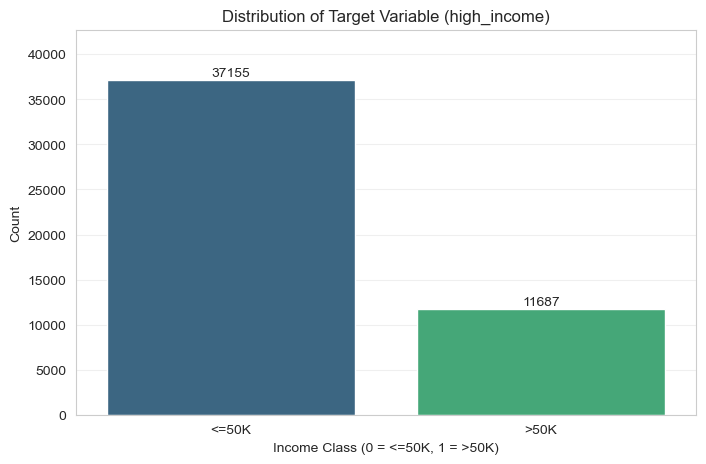

In [262]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='high_income', palette='viridis', hue='high_income', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Target Variable (high_income)')
plt.xlabel('Income Class (0 = <=50K, 1 = >50K)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['<=50K', '>50K'])
plt.ylim(0, max(counts) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Brief comment (1-2 sentences) on any class imbalance observed

The dataset exhibits a notable class imbalance, with the significant majority of individuals (roughly 76%) earning $50,000 or less, compared to the minority (roughly 24%) earning more. This means your future machine learning models will naturally be exposed to far more examples of the negative class, which can cause them to become biased toward predicting "<=50K" unless properly managed.

## **2. Train-Test Split and Feature Selection (20 points)**[¶](#2.-Train-Test-Split-and-Feature-Selection-(20-points))

In [266]:
# =============================================================================
# REDEFINE THE FUNCTION
# =============================================================================
def prepare_features(df, algorithm_type='both'):
    # Base Numerical Features
    base_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
    
    # Categorical Features
    cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
    
    df_model = df.copy()
    le = LabelEncoder()
    encoded_cols = []
    
    # Clean and Encode Categoricals
    for col in cat_features:
        # Convert to string to handle categories/NaNs safely
        df_model[col] = df_model[col].astype(str).replace('nan', 'Unknown').replace('?', 'Unknown')
        
        new_col_name = f"{col}_encoded"
        df_model[new_col_name] = le.fit_transform(df_model[col])
        encoded_cols.append(new_col_name)

    if algorithm_type == 'knn':
        features = base_features + encoded_cols
        X = df_model[features]
        
    elif algorithm_type == 'tree':
        # Feature Engineering for Tree
        # Age Group
        df_model['age_group'] = pd.cut(df_model['age'], bins=[0, 18, 30, 50, 70, 100], labels=['0-18', '19-30', '31-50', '51-70', '70+'])
        df_model['age_group_encoded'] = le.fit_transform(df_model['age_group'].astype(str))
        
        # Hours Group
        df_model['hours_group'] = pd.cut(df_model['hours_per_week'], bins=[0, 39, 40, 100], labels=['Part-time', 'Full-time', 'Overtime'])
        df_model['hours_group_encoded'] = le.fit_transform(df_model['hours_group'].astype(str))
        
        features = base_features + encoded_cols + ['age_group_encoded', 'hours_group_encoded']
        X = df_model[features]
        
    else: 
        features = base_features + encoded_cols
        X = df_model[features]
    
    y = df['high_income']
    return X, y, features

# =============================================================================
# EXECUTE
# =============================================================================
print("\n--- Running prepare_features for Tree ---")
X_tree, y_tree, tree_features = prepare_features(df, algorithm_type='tree')

print(f"Success! Features prepared: {len(tree_features)}")
print(f"Feature List: {tree_features}")


--- Running prepare_features for Tree ---
Success! Features prepared: 14
Feature List: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_encoded', 'marital_status_encoded', 'occupation_encoded', 'relationship_encoded', 'race_encoded', 'sex_encoded', 'native_country_encoded', 'age_group_encoded', 'hours_group_encoded']


### **Train-Test Split (5 points)**[¶](#Train-Test-Split-(5-points))

### Split the data into 80% train / 20% test & Use stratified sampling (random\_state = 42)[¶](#Split-the-data-into-80%25-train-/-20%25-test-&-Use-stratified-sampling-(random_state-=-42))

In [269]:
# Define your features (X) and target (y)
columns_to_drop = ['high_income', 'income'] 
X = df.drop(columns_to_drop, axis=1, errors='ignore') 
y = df['high_income']

# Now re-run your get_dummies (Option B) and Train/Test split code
X = pd.get_dummies(X, drop_first=True)

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,  # For reproducibility
    stratify = y
)


# Verify the split
print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"Total observations: {len(df):,}")
print(f"\nTraining set: {len(X_train):,} ({len(X_train)/len(df):.1%})")
print(f"Test set: {len(X_test):,} ({len(X_test)/len(df):.1%})")
print(f"\nTraining high income rate: {y_train.mean():.1%}")
print(f"Test high income rate: {y_test.mean():.1%}")

TRAIN/TEST SPLIT
Total observations: 48,842

Training set: 39,073 (80.0%)
Test set: 9,769 (20.0%)

Training high income rate: 23.9%
Test high income rate: 23.9%


### Display the shapes of training and testing sets[¶](#Display-the-shapes-of-training-and-testing-sets)

In [271]:
print("\n" + "="*60)
print("DATASET DIMENSIONS (SHAPES)")
print("="*60)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


DATASET DIMENSIONS (SHAPES)
X_train shape: (39073, 97)
X_test shape:  (9769, 97)
y_train shape: (39073,)
y_test shape:  (9769,)


### Verify target distribution is similar in both sets[¶](#Verify-target-distribution-is-similar-in-both-sets)

In [273]:
print("="*80)
print("TARGET DISTRIBUTION VERIFICATION")
print("="*80)

# Compare target distribution
print("\nTarget Variable Distribution:")
print("-" * 80)
comparison = pd.DataFrame({
    'Training Set': y_train.value_counts(normalize=True).sort_index(),
    'Test Set': y_test.value_counts(normalize=True).sort_index(),
    'Full Dataset': y.value_counts(normalize=True).sort_index()
})
comparison.index = ['≤50K (0)', '>50K (1)']
print(comparison)

print("\nAbsolute Counts:")
print("-" * 80)
counts = pd.DataFrame({
    'Training Set': y_train.value_counts().sort_index(),
    'Test Set': y_test.value_counts().sort_index(),
    'Full Dataset': y.value_counts().sort_index()
})
counts.index = ['≤50K (0)', '>50K (1)']
print(counts)

# Check if distributions are similar
diff = abs(y_train.mean() - y_test.mean())
print(f"\nDifference in high income rates: {diff:.3%}")
if diff < 0.02:
    print("✓ Distributions are very similar - good split!")
elif diff < 0.05:
    print("✓ Distributions are reasonably similar")
else:
    print("⚠️  Distributions differ significantly - consider stratified split")

print("\n" + "="*80)
print("TRAINING SET FEATURE STATISTICS")
print("="*80)

# First, let's see what we have
print("\nData types in X_train:")
print(X_train.dtypes.value_counts())

# Continuous variables
continuous_vars = ['age', 'fnlwgt', 'education.num', 'capital.gain', 
                   'capital.loss', 'hours_per_week']
available_cont_vars = [var for var in continuous_vars if var in X_train.columns]

print("\nCONTINUOUS VARIABLES:")
print("-" * 80)
cont_stats = X_train[available_cont_vars].describe().T
cont_stats['missing'] = X_train[available_cont_vars].isna().sum()
print(cont_stats.round(2))

# Get binary/numeric columns only
print("\n" + "="*80)
print("CATEGORICAL VARIABLES (Dummy Encoded Features):")
print("-" * 80)

numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
dummy_cols = [col for col in numeric_cols if col not in available_cont_vars]

print(f"\nFound {len(dummy_cols)} dummy variables")

if len(dummy_cols) > 0:
    # Calculate activation rate for each dummy
    dummy_stats = []
    for col in dummy_cols:
        activation_rate = X_train[col].mean()
        count = X_train[col].sum()
        dummy_stats.append({
            'Feature': col,
            'Activation Rate': activation_rate,
            'Count': int(count)
        })
    
    dummy_df = pd.DataFrame(dummy_stats).sort_values('Activation Rate', ascending=False)
    
    # Show top categories by type
    print("\nWorkclass (top 5):")
    workclass = dummy_df[dummy_df['Feature'].str.startswith('workclass_')].head(5)
    if len(workclass) > 0:
        print(workclass.to_string(index=False))
    else:
        print("  No workclass variables")
    
    print("\nEducation (top 5):")
    education = dummy_df[dummy_df['Feature'].str.startswith('education_')].head(5)
    if len(education) > 0:
        print(education.to_string(index=False))
    else:
        print("  No education variables")
    
    print("\nOccupation (top 5):")
    occupation = dummy_df[dummy_df['Feature'].str.startswith('occupation_')].head(5)
    if len(occupation) > 0:
        print(occupation.to_string(index=False))
    else:
        print("  No occupation variables")
    
    print("\nMarital Status:")
    marital = dummy_df[dummy_df['Feature'].str.startswith('marital.status_')]
    if len(marital) > 0:
        print(marital.to_string(index=False))
    else:
        print("  No marital status variables")
    
    print("\nSex:")
    sex = dummy_df[dummy_df['Feature'].str.startswith('sex_')]
    if len(sex) > 0:
        print(sex.to_string(index=False))
    else:
        print("  No sex variables")
else:
    print("\n⚠️  No dummy variables found!")
    print("Your X_train might still have categorical variables that need encoding.")
    print("\nNon-numeric columns in X_train:")
    non_numeric = X_train.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    print(non_numeric)

print("\n" + "="*80)
print("TRAINING SET SHAPE")
print("="*80)
print(f"Number of observations: {X_train.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]:,}")
print(f"\nFeature breakdown:")
print(f"  Continuous variables: {len(available_cont_vars)}")
print(f"  Dummy variables: {len(dummy_cols) if len(dummy_cols) > 0 else 0}")

TARGET DISTRIBUTION VERIFICATION

Target Variable Distribution:
--------------------------------------------------------------------------------
          Training Set  Test Set  Full Dataset
≤50K (0)       0.76073  0.760672      0.760718
>50K (1)       0.23927  0.239328      0.239282

Absolute Counts:
--------------------------------------------------------------------------------
          Training Set  Test Set  Full Dataset
≤50K (0)         29724      7431         37155
>50K (1)          9349      2338         11687

Difference in high income rates: 0.006%
✓ Distributions are very similar - good split!

TRAINING SET FEATURE STATISTICS

Data types in X_train:
bool     91
int64     6
Name: count, dtype: int64

CONTINUOUS VARIABLES:
--------------------------------------------------------------------------------
                  count       mean        std      min       25%       50%       75%        max  missing
age             39073.0      38.70      13.74     17.0      28.0      

### Random Forest Feature Selection (7 points)

### **Decision Tree for Feature Selection (15 points)**[¶](#Decision-Tree-for-Feature-Selection-(15-points))

### Train a Decision Tree classifier on the training set using all available features[¶](#Train-a-Decision-Tree-classifier-on-the-training-set-using-all-available-features)

In [277]:
# Initialize Decision Tree
dt_full = DecisionTreeClassifier(random_state=42)

# Train the model on the full training set
dt_full.fit(X_train, y_train)

# Verification
print(f"Model Depth: {dt_full.get_depth()}")
print(f"Number of Leaves: {dt_full.get_n_leaves()}")
print(f"Training Accuracy: {dt_full.score(X_train, y_train):.2%}")

Model Depth: 54
Number of Leaves: 5766
Training Accuracy: 99.99%


### Extract feature importance scores from the trained decision tree & Create a visualization (bar plot) showing feature importance scores & Select the top 12 most important features based on the importance scores[¶](#Extract-feature-importance-scores-from-the-trained-decision-tree-&-Create-a-visualization-(bar-plot)-showing-feature-importance-scores-&-Select-the-top-12-most-important-features-based-on-the-importance-scores)


TOP 12 MOST IMPORTANT FEATURES:
                          Feature  Importance
marital_status_Married-civ-spouse    0.201805
                           fnlwgt    0.192107
                    education_num    0.108617
                              age    0.106303
                     capital_gain    0.105180
                   hours_per_week    0.066266
                     capital_loss    0.041321
                workclass_Private    0.011145
          occupation_Craft-repair    0.010320
       occupation_Exec-managerial    0.009772
       workclass_Self-emp-not-inc    0.009403
                 occupation_Sales    0.008845


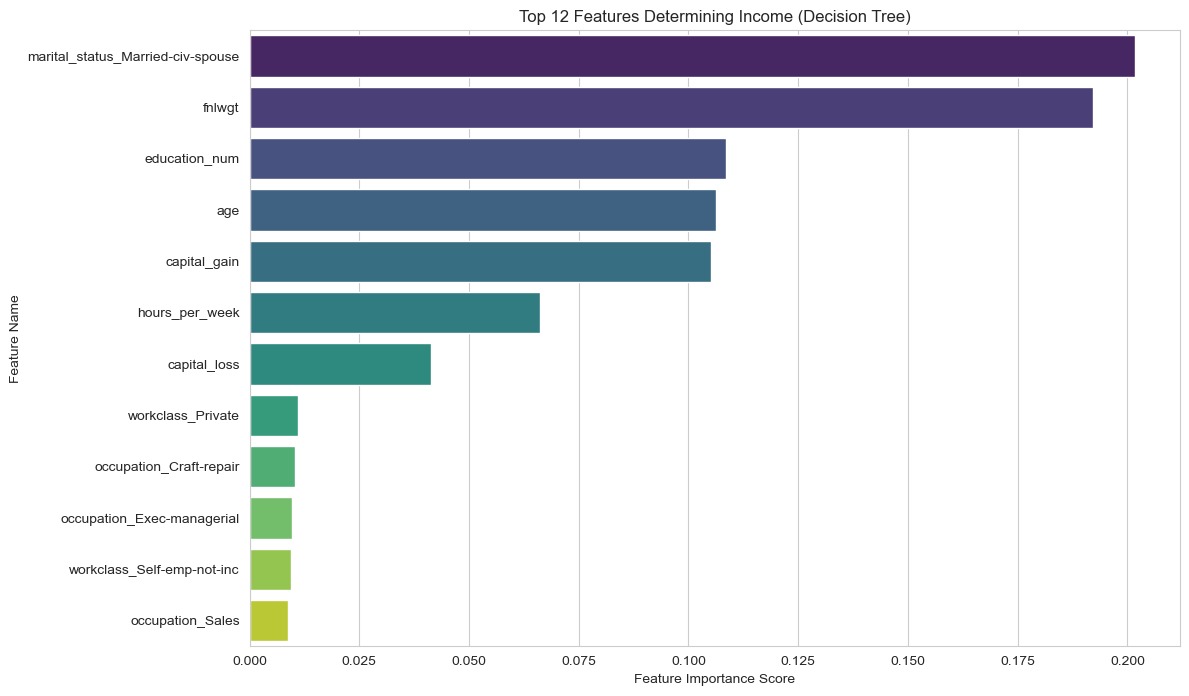

In [279]:
# Extract Feature Importances
importances = dt_full.feature_importances_
feature_names = X_train.columns

# Organize
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by Importance (Highest to Lowest)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the Top 20 Features
print("\nTOP 12 MOST IMPORTANT FEATURES:")
print(feature_importance_df.head(12).to_string(index=False))

# Visualize the Top 10 Features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(12), palette='viridis')
plt.title('Top 12 Features Determining Income (Decision Tree)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.show()

### Create a table showing: Feature name, Importance score, Selected (Yes/No)[¶](#Create-a-table-showing:-Feature-name,-Importance-score,-Selected-(Yes/No))

In [281]:
# Create the 'Selected' column
# Initialize all as 'No' first
feature_importance_df['Selected'] = 'No'

# Top 12 features as 'Yes'
feature_importance_df.iloc[:12, feature_importance_df.columns.get_loc('Selected')] = 'Yes'

# Rename columns to match
selection_table = feature_importance_df.rename(columns={
    'Feature': 'Feature name',
    'Importance': 'Importance score'
})


print("\nFEATURE SELECTION SUMMARY TABLE")
print(selection_table.head(20).to_string(index=False))


FEATURE SELECTION SUMMARY TABLE
                     Feature name  Importance score Selected
marital_status_Married-civ-spouse          0.201805      Yes
                           fnlwgt          0.192107      Yes
                    education_num          0.108617      Yes
                              age          0.106303      Yes
                     capital_gain          0.105180      Yes
                   hours_per_week          0.066266      Yes
                     capital_loss          0.041321      Yes
                workclass_Private          0.011145      Yes
          occupation_Craft-repair          0.010320      Yes
       occupation_Exec-managerial          0.009772      Yes
       workclass_Self-emp-not-inc          0.009403      Yes
                 occupation_Sales          0.008845      Yes
        occupation_Prof-specialty          0.008240       No
                         sex_Male          0.007652       No
           workclass_Self-emp-inc          0.006777 

### Prepare the reduced feature set (X\_train\_selected, X\_test\_selected) for model training[¶](#Prepare-the-reduced-feature-set-(X_train_selected,-X_test_selected)-for-model-training)

In [283]:
top_12_features = feature_importance_df.head(12)['Feature'].tolist()

# Filter  original X_train and X_test to include only the 12 columns
X_train_selected = X_train[top_12_features]
X_test_selected = X_test[top_12_features]

# Verification
print("FEATURE REDUCTION VERIFICATION")
print(f"Original feature count: {X_train.shape[1]}")
print(f"Reduced feature count:  {X_train_selected.shape[1]}")
print("\nSelected Features:")
for i, feat in enumerate(top_12_features, 1):
    print(f"{i}. {feat}")

print("\nNew Shapes:")
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected:  {X_test_selected.shape}")

FEATURE REDUCTION VERIFICATION
Original feature count: 97
Reduced feature count:  12

Selected Features:
1. marital_status_Married-civ-spouse
2. fnlwgt
3. education_num
4. age
5. capital_gain
6. hours_per_week
7. capital_loss
8. workclass_Private
9. occupation_Craft-repair
10. occupation_Exec-managerial
11. workclass_Self-emp-not-inc
12. occupation_Sales

New Shapes:
X_train_selected: (39073, 12)
X_test_selected:  (9769, 12)


### Random Forest

* Train a Random Forest classifier using RandomForestClassifier(n_estimators=100, random_state=42) on the training set with all available features
* Extract feature importance scores from the trained Random Forest
* Create a visualization (bar plot) showing all feature importance scores, sorted from highest to lowest
* Select the top 12 most important features based on importance scores


MODEL TRAINING - RANDOM FOREST
Top 2 features: 0.7284 - ['marital_status_Married-civ-spouse', 'fnlwgt']
Top 3 features: 0.7677 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num']
Top 4 features: 0.7839 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age']
Top 5 features: 0.8189 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age', 'capital_gain']
Top 6 features: 0.8325 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age', 'capital_gain', 'hours_per_week']
Top 7 features: 0.8424 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age', 'capital_gain', 'hours_per_week', 'capital_loss']
Top 8 features: 0.8432 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age', 'capital_gain', 'hours_per_week', 'capital_loss', 'workclass_Private']
Top 9 features: 0.8464 - ['marital_status_Married-civ-spouse', 'fnlwgt', 'education_num', 'age', 'capital_gain', 'hours_per_week', 'capital_loss', 'w

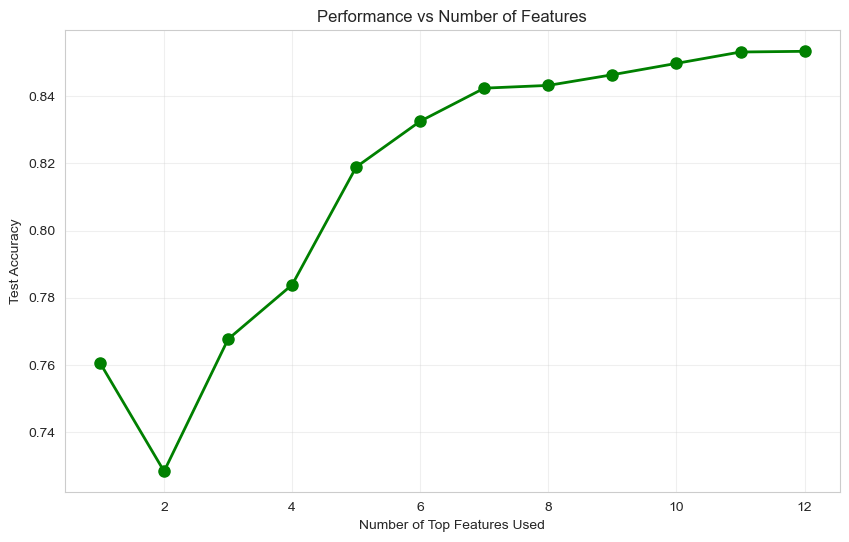

In [286]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================================
# MODEL TRAINING - RANDOM FOREST
# ============================================================================
print("\n" + "=" * 60)
print("MODEL TRAINING - RANDOM FOREST")
print("=" * 60)

feature_selection_results = []

# Variables to keep track of the best performing model
best_score = 0
best_n = 0

# Loop from 1 feature up to the total number of top features
number_of_features_to_test = range(1, len(top_12_features) + 1)

for n in number_of_features_to_test:
    
    selected_cols = top_12_features[:n]
    X_train_selected = X_train[selected_cols]
    X_test_selected = X_test[selected_cols]
    
    rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_selected.fit(X_train_selected, y_train)
    
    score = rf_selected.score(X_test_selected, y_test)
    feature_selection_results.append(score)
    
    # Check if this is the best score we've seen so far
    if score > best_score:
        best_score = score
        best_n = n
        
    if n >= 2:
        print(f"Top {n} features: {score:.4f} - {selected_cols}")

print(f"\nBest performance with {best_n} features: {best_score:.4f}")

# Plot results
plt.figure(figsize=(10, 6))

plt.plot(list(number_of_features_to_test), feature_selection_results, 'go-', linewidth=2, markersize=8)

plt.xlabel('Number of Top Features Used')
plt.ylabel('Test Accuracy')
plt.title('Performance vs Number of Features')
plt.grid(True, alpha=0.3)
plt.show()

### Create a table showing:
* Feature name
* Importance score (rounded to 4 decimal places)
* Selected (Yes/No)

In [288]:
import pandas as pd

# ============================================================================
# FEATURE IMPORTANCE & SELECTION SUMMARY
# ============================================================================

# Extract importances from the final model in your loop
importances = rf_selected.feature_importances_

# Create the DataFrame
feature_summary_df = pd.DataFrame({
    'Feature Name': top_12_features,
    'Importance Score': importances
})

# Sort by importance to ensure they are in the correct rank order
feature_summary_df = feature_summary_df.sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

# Round the scores to 4 decimal places
feature_summary_df['Importance Score'] = feature_summary_df['Importance Score'].round(4)

# Add the 'Selected' column based on the best_n found in your loop
feature_summary_df['Selected'] = ['Yes' if i < best_n else 'No' for i in range(len(feature_summary_df))]

# Display the final table
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE & SELECTION SUMMARY")
print("=" * 60)
print(feature_summary_df.to_string(index=False))


FEATURE IMPORTANCE & SELECTION SUMMARY
                     Feature Name  Importance Score Selected
                           fnlwgt            0.2438      Yes
                              age            0.1734      Yes
marital_status_Married-civ-spouse            0.1538      Yes
                    education_num            0.1198      Yes
                     capital_gain            0.1161      Yes
                   hours_per_week            0.0938      Yes
                     capital_loss            0.0427      Yes
       occupation_Exec-managerial            0.0207      Yes
                workclass_Private            0.0117      Yes
       workclass_Self-emp-not-inc            0.0083      Yes
                 occupation_Sales            0.0079      Yes
          occupation_Craft-repair            0.0079      Yes


### Brief interpretation (2-3 sentences): Why might Random Forest feature selection be more robust than single Decision Tree feature selection?

Random Forest feature selection is more robust because it averages the importance scores across hundreds of different decision trees, each trained on a random subset of both the data and the features. This ensemble approach neutralizes the high variance of a single Decision Tree, preventing the importance scores from being skewed by a single overfitted model or a specific quirk in the training data.

### All subsequent models (Section 3) will be trained using this feature-selected dataset (12 features only).

In [292]:
X_train_selected = X_train[top_12_features]
X_test_selected = X_test[top_12_features]

print("Feature-selected datasets successfully created with", X_train_selected.shape[1], "features.")

Feature-selected datasets successfully created with 12 features.


## **3. Six-Model Training and Comparison (25 points)**[¶](#3.-Four-Model-Training-and-Comparison-(25-points))

### **a) Model Training (15 points)**[¶](#a)-Model-Training-(15-points))

### 1. Linear Probability Model (LPM) - using sklearn.linear\_model.LinearRegression[¶](#1.-Linear-Probability-Model-(LPM)---using-sklearn.linear_model.LinearRegression)

* Display model coefficients with feature names
* Show Model Summary

In [296]:
from sklearn.linear_model import LinearRegression

# Prepare the data
# Remove non-numeric features and the target to avoid leakage
cols_to_remove = ['age_group', 'hours_group', 'income_=50K', 'high_income', 'income']
X_train_clean = X_train.drop(columns=[col for col in cols_to_remove if col in X_train.columns])
X_test_clean = X_test.drop(columns=[col for col in cols_to_remove if col in X_test.columns])

# Convert boolean to int
X_train_clean = X_train_clean.astype(int)
X_test_clean = X_test_clean.astype(int)

# Train the LPM
lpm = LinearRegression()
lpm.fit(X_train_selected, y_train)

# Extract Coefficients and Intercept
lpm_summary = pd.DataFrame({
    'Feature name': X_train_selected.columns,
    'Coefficient': lpm.coef_
})

# Add Intercept to the table
intercept_row = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [lpm.intercept_]})
lpm_summary = pd.concat([intercept_row, lpm_summary], ignore_index=True)

# Display the results
print("LPM")
print(f"Features in model: {X_train_selected.shape[1]}")
print(f"Includes all dummy variables: {X_train_selected.shape[1] > 90}")
print(f"Model R-squared: {lpm.score(X_train_selected, y_train):.4f}")

print("\n" + "="*80)
print("MODEL SUMMARY: COEFFICIENTS")

# Display top 20 most impactful coefficients or the full list
# Sort by absolute value to see which features change the probability the most
lpm_summary['Abs_Coef'] = lpm_summary['Coefficient'].abs()
sorted_summary = lpm_summary.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

print(sorted_summary.to_string(index=False))

print("\n" + "="*80)
print("COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)")
for _, row in sorted_summary.iterrows():
    print(f"{row['Feature name']:35s}: {row['Coefficient']:10.4f}")

LPM
Features in model: 12
Includes all dummy variables: False
Model R-squared: 0.3478

MODEL SUMMARY: COEFFICIENTS
                     Feature name   Coefficient
                      (Intercept) -5.552765e-01
marital_status_Married-civ-spouse  3.099881e-01
       occupation_Exec-managerial  1.306048e-01
       workclass_Self-emp-not-inc -8.167061e-02
                 occupation_Sales  4.103998e-02
                    education_num  3.965846e-02
                workclass_Private -9.539640e-03
          occupation_Craft-repair -4.285041e-03
                   hours_per_week  2.768661e-03
                              age  2.599975e-03
                     capital_loss  9.769450e-05
                     capital_gain  8.558650e-06
                           fnlwgt  8.103970e-08

COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)
(Intercept)                        :    -0.5553
marital_status_Married-civ-spouse  :     0.3100
occupation_Exec-managerial         :     0.1306
workclass_Self-emp-not-in

### 2. Logistic Regression - using sklearn.linear\_model.LogisticRegression[¶](#2.-Logistic-Regression---using-sklearn.linear_model.LogisticRegression)

* Display model coefficients with feature names
* Show Model Summary

In [298]:
from sklearn.linear_model import LogisticRegression

# Initialize Logit
# We increase max_iter to ensure the solver finds the optimal coefficients
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model using the REDUCED feature set
log_reg.fit(X_train_selected, y_train)

# Extract Coefficients and Intercept
log_summary = pd.DataFrame({
    'Feature name': X_train_selected.columns,
    'Coefficient': log_reg.coef_[0]
})

# Add the Intercept
log_intercept = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [log_reg.intercept_[0]]})
log_summary = pd.concat([log_intercept, log_summary], ignore_index=True)

# Display Model Summary
print("LOGIT")
print("="*80)
print(f"Number of features used: {X_train_selected.shape[1]}")
print(f"Training Accuracy:       {log_reg.score(X_train_selected, y_train):.4f}")
print(f"Intercept:              {log_reg.intercept_[0]:.4f}")

print("\n" + "="*80)
print(f"{'Feature Name':<35} | {'Coefficient':>12}")
print("-" * 80)

# Sort by absolute coefficient value to show importance
log_summary['abs_val'] = log_summary['Coefficient'].abs()
sorted_log = log_summary.sort_values('abs_val', ascending=False).drop(columns=['abs_val'])

for _, row in sorted_log.iterrows():
    print(f"{row['Feature name']:<35} | {row['Coefficient']:>12.4f}")

# 5. Optional: Odds Ratios (Easier to interpret than raw coefficients)
print("\n" + "="*80)
print("ODDS RATIOS (exp(coef))")
print("="*80)
# Odds ratio > 1 means the feature increases the likelihood of high income
for _, row in sorted_log.iterrows():
    if row['Feature name'] != '(Intercept)':
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature name']:<35} | {odds_ratio:>12.4f}")

LOGIT
Number of features used: 12
Training Accuracy:       0.8263
Intercept:              -2.6747

Feature Name                        |  Coefficient
--------------------------------------------------------------------------------
marital_status_Married-civ-spouse   |       2.7886
(Intercept)                         |      -2.6747
occupation_Exec-managerial          |       1.3257
workclass_Self-emp-not-inc          |      -0.9606
occupation_Craft-repair             |      -0.3877
occupation_Sales                    |       0.2487
workclass_Private                   |      -0.2098
education_num                       |       0.0933
age                                 |      -0.0150
hours_per_week                      |      -0.0090
capital_loss                        |       0.0007
capital_gain                        |       0.0003
fnlwgt                              |      -0.0000

ODDS RATIOS (exp(coef))
marital_status_Married-civ-spouse   |      16.2585
occupation_Exec-managerial    

### K-Nearest Neighbors (K=9) - using sklearn.neighbors.KNeighborsClassifier[¶](#K-Nearest-Neighbors-(K=9)---using-sklearn.neighbors.KNeighborsClassifier)

* Use k=9 neighbors
* Note: KNN is non-parametric, so no coefficients to display

In [300]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=9)

# Fit the model (Using SCALED data)
knn_model.fit(X_train_scaled, y_train)

# Verification
print("K-NEAREST NEIGHBORS (K=9) RESULTS")
print(f"Features used: {len(top_12_features)}")

# Calculate scores (Using SCALED data and correct Test data)
train_score = knn_model.score(X_train_scaled, y_train)
test_score = knn_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_score:.4%}")
print(f"Test Accuracy:     {test_score:.4%}")

print("\n" + "="*60)
print("MODEL PARAMETERS")
print("="*60)
print(f"Metric:            {knn_model.metric}")
print(f"Weights:           {knn_model.weights}")
print(f"Algorithm:         {knn_model.algorithm}")

K-NEAREST NEIGHBORS (K=9) RESULTS
Features used: 12
Training Accuracy: 86.9526%
Test Accuracy:     84.1335%

MODEL PARAMETERS
Metric:            minkowski
Weights:           uniform
Algorithm:         auto


### 3. Decision Tree - using sklearn.tree.DecisionTreeClassifier[¶](#Decision-Tree---using-sklearn.tree.DecisionTreeClassifier)

* Use default parameters
* Calculate training accuracy
* Extract and display feature importance from this model as well

In [302]:
# Initialize and Train the Decision Tree with default parameters
dt_selected = DecisionTreeClassifier(random_state=42)
dt_selected.fit(X_train_selected, y_train)

# Calculate Training AND Test Accuracy (Variables properly named!)
single_train_acc = dt_selected.score(X_train_selected, y_train)
single_test_acc = dt_selected.score(X_test_selected, y_test)

# Extract Feature Importances
importances_reduced = dt_selected.feature_importances_
feature_names_reduced = X_train_selected.columns

# DataFrame
dt_reduced_importance_df = pd.DataFrame({
    'Feature': feature_names_reduced,
    'Importance': importances_reduced
}).sort_values(by='Importance', ascending=False)

# Display
print("DECISION TREE MODEL RESULTS (REDUCED FEATURES)")
print(f"Training Accuracy: {single_train_acc:.4f}")
print(f"Test Accuracy: {single_test_acc:.4f}")
print(f"Overfitting: {single_train_acc - single_test_acc:.4f}")

print("\nFEATURE IMPORTANCE (FROM REDUCED MODEL):")
print("-" * 60)
print(dt_reduced_importance_df.to_string(index=False))

DECISION TREE MODEL RESULTS (REDUCED FEATURES)
Training Accuracy: 0.9998
Test Accuracy: 0.8139
Overfitting: 0.1859

FEATURE IMPORTANCE (FROM REDUCED MODEL):
------------------------------------------------------------
                          Feature  Importance
                           fnlwgt    0.268961
marital_status_Married-civ-spouse    0.201862
                              age    0.124074
                    education_num    0.120003
                     capital_gain    0.105627
                   hours_per_week    0.076717
                     capital_loss    0.042113
                workclass_Private    0.017249
                 occupation_Sales    0.011902
          occupation_Craft-repair    0.011790
       occupation_Exec-managerial    0.010924
       workclass_Self-emp-not-inc    0.008776


### 4. Bagging Classifier (5 points)

In [304]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# ============================================================================
# MODEL TRAINING - BAGGING
# ============================================================================
print("\n" + "=" * 60)
print("MODEL TRAINING - BAGGING")
print("=" * 60)

# Updated to include random_state=42 inside the DecisionTreeClassifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),  
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train_selected, y_train)

bagging_train_acc = bagging_model.score(X_train_selected, y_train)
bagging_test_acc = bagging_model.score(X_test_selected, y_test)

print(f"\nBagging (100 Decision Trees):")
print(f"• Training Accuracy: {bagging_train_acc:.4f}")
print(f"• Test Accuracy: {bagging_test_acc:.4f}")
print(f"• Overfitting: {bagging_train_acc - bagging_test_acc:.4f}")

# Assuming single_test_acc and single_train_acc are defined earlier in your script
print(f"\nImprovement from Bagging:")
print(f"• Test accuracy improved by: {bagging_test_acc - single_test_acc:.4f}")
print(f"• Overfitting reduced by: {(single_train_acc - single_test_acc) - (bagging_train_acc - bagging_test_acc):.4f}")


MODEL TRAINING - BAGGING

Bagging (100 Decision Trees):
• Training Accuracy: 0.9998
• Test Accuracy: 0.8528
• Overfitting: 0.1470

Improvement from Bagging:
• Test accuracy improved by: 0.0389
• Overfitting reduced by: 0.0389


### Brief explanation (2-3 sentences): How does bagging reduce variance compared to a single decision tree?

Bagging reduces variance by training multiple independent decision trees on different random subsets of the training data (created via bootstrapping) and averaging their final predictions. Because a single decision tree is highly sensitive to the specific data it is trained on and is prone to overfitting, combining hundreds of slightly different trees allows their individual errors and "quirks" to cancel each other out. This results in a final ensemble model that is much more stable and generalizes better to unseen data.

### Random Forest (6 points)

* Use sklearn.ensemble.RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
* Calculate training accuracy
* Extract and display feature importances for all 12 selected features
* Create visualization of feature importances (bar plot)
* Brief explanation (2-3 sentences): How does Random Forest differ from standard Bagging?


MODEL TRAINING - RANDOM FOREST
• Training Accuracy: 0.8694
• Test Accuracy: 0.8640

FEATURE IMPORTANCES:
----------------------------------------
                          Feature  Importance
marital_status_Married-civ-spouse    0.309050
                     capital_gain    0.220688
                    education_num    0.169153
                              age    0.097631
                     capital_loss    0.068379
                   hours_per_week    0.065460
       occupation_Exec-managerial    0.033880
                           fnlwgt    0.019412
       workclass_Self-emp-not-inc    0.006512
                workclass_Private    0.004103
          occupation_Craft-repair    0.003559
                 occupation_Sales    0.002174


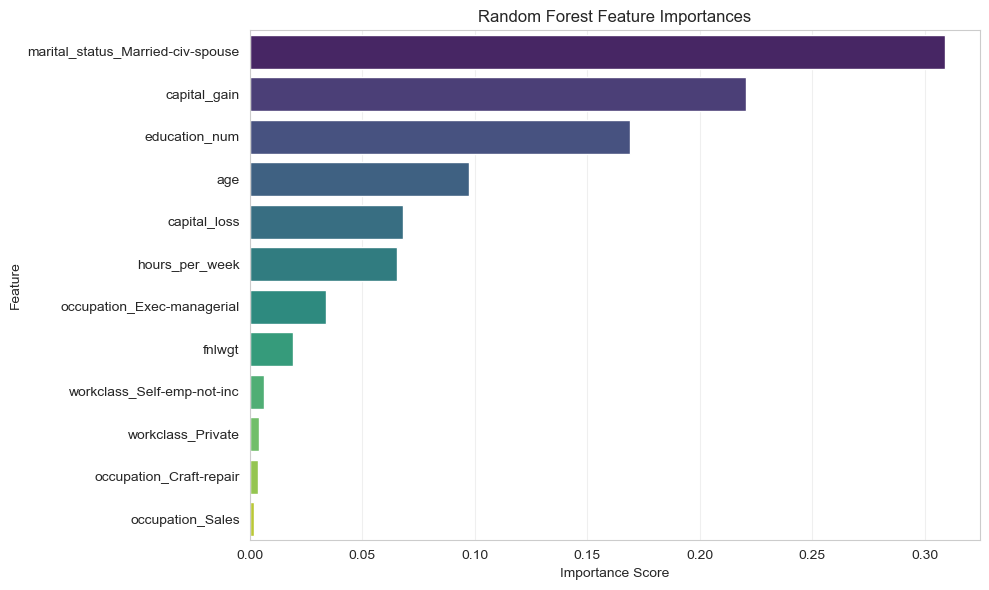

In [308]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ============================================================================
# MODEL TRAINING - RANDOM FOREST (Final 12 Features)
# ============================================================================
print("\n" + "=" * 60)
print("MODEL TRAINING - RANDOM FOREST")
print("=" * 60)

# 1. Initialize with EXACT requested parameters
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

# Fit the model
rf_model.fit(X_train_selected, y_train)

# 2. Calculate training accuracy
rf_train_acc = rf_model.score(X_train_selected, y_train)
rf_test_acc = rf_model.score(X_test_selected, y_test) # Good practice to show both

print(f"• Training Accuracy: {rf_train_acc:.4f}")
print(f"• Test Accuracy: {rf_test_acc:.4f}\n")

# 3. Extract and display feature importances for all 12 selected features
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print("FEATURE IMPORTANCES:")
print("-" * 40)
print(rf_importance_df.to_string(index=False))

# 4. Create visualization of feature importances (bar plot)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

While both methods build multiple decision trees using bootstrapped subsets of the data, standard Bagging evaluates all available features when making a split at every node. Random Forest introduces "feature randomness" by only allowing a random subset of features to be considered at each split. This prevents a few highly dominant features from taking over every tree, creating a more diverse "forest" that better reduces variance and prevents overfitting.

## 5. **AdaBoost**

In [311]:
# n_estimators_list = [1, 5, 10, 25, 50, 100, 200]
ada_scores = []

print(f"{'Weak Learners':<15} {'Test Accuracy':<15}")
print("-" * 45)

n=100

# Create AdaBoost model
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=n,
    random_state=42,
    learning_rate=1.0
)
# Train model
ada_model.fit(X_train_selected, y_train)
    
# Get accuracy
adaboost_acc = ada_model.score(X_test_selected, y_test)
#ada_scores.append(test_acc)

print(f"{n:<15} {adaboost_acc:<15.4f}")

Weak Learners   Test Accuracy  
---------------------------------------------
100             0.8630         


### AdaBoost - Feature Importance

Feature Importance Ranking:

capital_gain    0.4300
capital_loss    0.2200
education_num   0.1100
age             0.1000
fnlwgt          0.0700
hours_per_week  0.0300
marital_status_Married-civ-spouse 0.0100
occupation_Exec-managerial 0.0100
workclass_Self-emp-not-inc 0.0100
occupation_Sales 0.0100
workclass_Private 0.0000
occupation_Craft-repair 0.0000


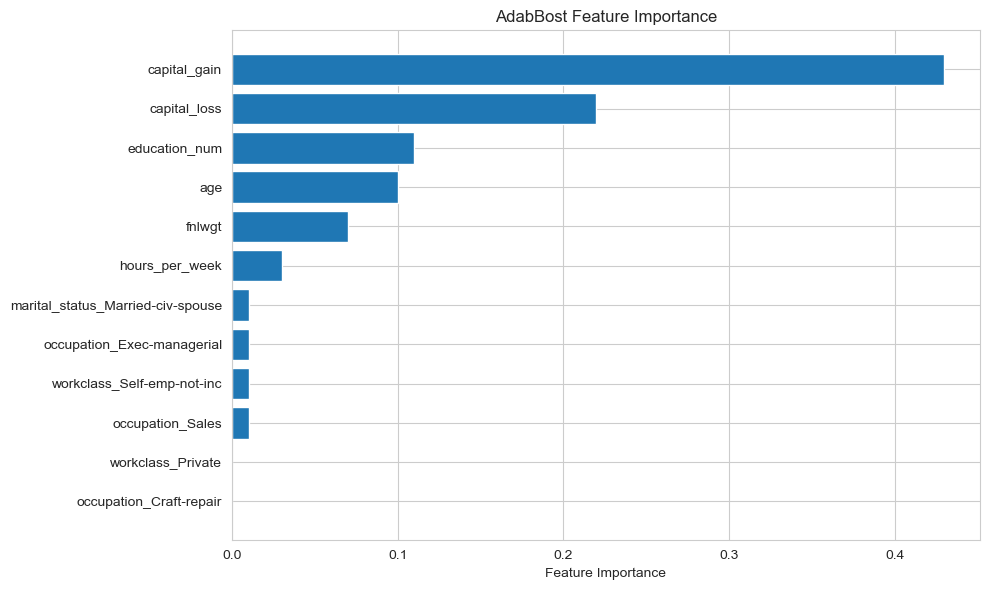


Most important feature: capital_gain
Least important feature: occupation_Craft-repair


In [313]:
# Get feature importance
feature_importance = ada_model.feature_importances_

print("Feature Importance Ranking:\n")
importance_df = pd.DataFrame({
    'Feature': top_12_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

for i, row in importance_df.iterrows():
    print(f"{row['Feature']:15} {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(importance_df)), importance_df['Importance'])
plt.yticks(range(len(importance_df)), importance_df['Feature'])
plt.xlabel('Feature Importance')
plt.title('AdabBost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nMost important feature: {importance_df.iloc[0]['Feature']}")
print(f"Least important feature: {importance_df.iloc[-1]['Feature']}")

### AdaBoost - Detailed Explanation
- How does AdaBoost sequentially focus on misclassified samples?
> AdaBoost works by building models one after another, where each new model is specifically designed to correct the mistakes of the previous one.
- What is the role of sample weights in AdaBoost?
> Sample weights act as a priority system. At first, all data points are equally important, but when a model guesses a point incorrectly, that point's weight is increased. This makes the misclassified point "heavier," forcing the next model in the sequence to prioritize fixing that specific error.
- Why use weak learners (stumps with max_depth=1)?
> The algorithm intentionally uses weak learners, like decision stumps with only a single split, because they are incredibly simple and prevent the model from memorizing or overfitting the training data. By combining hundreds of these basic rules the algorithm slowly builds a very strong final prediction without being overly complex.
- How does the learning_rate parameter affect the algorithm?
> The learning rate controls how much poweris given to each weak learner's prediction. A lower learning rate shrinks the impact of each individual tree.

## **6. Gradient Boosting**

In [316]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    learning_rate=0.1
)

gb_model.fit(X_train_selected, y_train)
gb_final_score = gb_model.score(X_test_selected, y_test)

### Gradient Boosting VS AdaBoost

In [318]:
print(f"AdaBoost:  {adaboost_acc:.4f}")
print(f"Gradient Boost:  {gb_final_score:.4f}")

if gb_final_score > adaboost_acc:
    print(f"\nGradient Boosting wins by {gb_final_score - adaboost_acc:.4f}!")
else:
    print(f"\nAdaBoost wins by {adaboost_acc - gb_final_score:.4f}!")

AdaBoost:  0.8630
Gradient Boost:  0.8670

Gradient Boosting wins by 0.0040!


### Gradient Boosting - Feature Importance

Feature Importance Ranking:

marital_status_Married-civ-spouse 0.4014
education_num   0.2031
capital_gain    0.2023
capital_loss    0.0672
age             0.0604
hours_per_week  0.0348
occupation_Exec-managerial 0.0208
workclass_Self-emp-not-inc 0.0063
fnlwgt          0.0028
occupation_Sales 0.0006
workclass_Private 0.0002
occupation_Craft-repair 0.0001


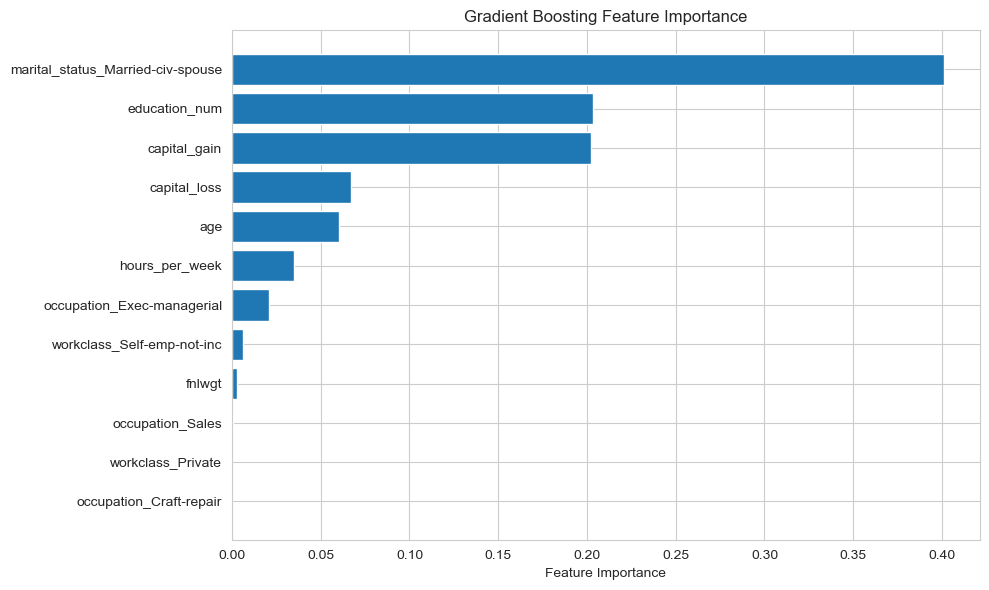


Most important feature: marital_status_Married-civ-spouse
Least important feature: occupation_Craft-repair


In [320]:
# Get feature importance
feature_importance = gb_model.feature_importances_

print("Feature Importance Ranking:\n")
importance_df = pd.DataFrame({
    'Feature': top_12_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

for i, row in importance_df.iterrows():
    print(f"{row['Feature']:15} {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(importance_df)), importance_df['Importance'])
plt.yticks(range(len(importance_df)), importance_df['Feature'])
plt.xlabel('Feature Importance')
plt.title('Gradient Boosting Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nMost important feature: {importance_df.iloc[0]['Feature']}")
print(f"Least important feature: {importance_df.iloc[-1]['Feature']}")

### Gradient Boosting - Detailed Explanation
- How does Gradient Boosting differ from AdaBoost in its approach?
> While AdaBoost forces new models to focus on mistakes by making misclassified data points "heavier", Gradient Boosting calculates the exact mathematical difference between the current prediction and the actual true value.
- Explain the concept of fitting to residual errors
> Fitting to residual errors means that each new tree in the sequence does not try to predict the final target.
- What is the role of the learning_rate parameter?
> The learning rate acts as a brake pedal that controls how much impact each new tree is allowed to have on the final answer. Instead of fully trusting and adding the complete correction from a newly built tree, the algorithm only adds a small fraction of it.
- How does Gradient Boosting minimize the loss function?
> The loss function is a mathematical score that measures how wrong the model is overall. Gradient Boosting minimizes this loss by taking small, carefully calculated steps in the right direction.  Each new tree calculates the mathematical path that will reduce the remaining errors the fastest, slowly pushing the overall model down to the lowest possible error rate.
- Why might Gradient Boosting outperform AdaBoost?
> Gradient Boosting might outperform AdaBoost because its mathematical approach of targeting exact errors is more precise. Gradient Boosting handles complex patterns and outliers more gracefully, making it a stronger overall performer on real-world datasets.

### Training Summary Table

In [323]:
import pandas as pd

print("\n" + "=" * 140)
print(f"{'TRAINING SUMMARY TABLE':^150}")
print("=" * 140)

# Compile the data using the variables already stored in your environment
summary_data = [
    {
        "Model Name": "Linear Probability Model (LPM)",
        "Training Accuracy": f"{lpm.score(X_train_selected, y_train):.4f}",
        "Ensemble Type": "None",
        "Number of Estimators": "N/A",
        "Learning Approach": "Single Model",
        "Complexity / Parameters": "13 parameters (12 features + 1 intercept)",
        "Observations on Overfitting": "Low risk. Rigid linear model (high bias); unlikely to overfit."
    },
    {
        "Model Name": "Logistic Regression",
        "Training Accuracy": f"{log_reg.score(X_train_selected, y_train):.4f}",
        "Ensemble Type": "None",
        "Number of Estimators": "N/A",
        "Learning Approach": "Single Model",
        "Complexity / Parameters": "13 parameters (12 features + 1 intercept)",
        "Observations on Overfitting": "Low risk. Constrained by a linear decision boundary."
    },
    {
        "Model Name": "K-Nearest Neighbors (K=9)",
        "Training Accuracy": f"{train_score:.4f}", # From your scaled KNN block
        "Ensemble Type": "None",
        "Number of Estimators": "N/A",
        "Learning Approach": "Single Model",
        "Complexity / Parameters": "Non-parametric (Stores entire training dataset)",
        "Observations on Overfitting": "Moderate risk. K=9 provides smoothing, but still sensitive to local clusters."
    },
    {
        "Model Name": "Decision Tree (Default)",
        "Training Accuracy": f"{single_train_acc:.4f}",
        "Ensemble Type": "None",
        "Number of Estimators": "1",
        "Learning Approach": "Single Model",
        "Complexity / Parameters": "High complexity (Unconstrained nodes/depth)",
        "Observations on Overfitting": "Very High risk. Grown until it perfectly memorized training data."
    },
    {
        "Model Name": "Bagging (100 Trees)",
        "Training Accuracy": f"{bagging_train_acc:.4f}",
        "Ensemble Type": "Bagging",
        "Number of Estimators": "100",
        "Learning Approach": "Parallel (Independent)",
        "Complexity / Parameters": "Very High (100 unpruned decision trees)",
        "Observations on Overfitting": "High memorization, better generalization. Averaging neutralizes variance."
    },
    {
        "Model Name": "Random Forest",
        "Training Accuracy": f"{rf_train_acc:.4f}",
        "Ensemble Type": "Bagging",
        "Number of Estimators": "100",
        "Learning Approach": "Parallel (Independent)",
        "Complexity / Parameters": "Moderate-High (100 trees, max_depth=10)",
        "Observations on Overfitting": "Low risk. Limited depth and feature randomness prevent overfitting."
    },
    {
        "Model Name": "AdaBoost",
        "Training Accuracy": f"{ada_model.score(X_train_selected, y_train):.4f}", 
        "Ensemble Type": "Boosting",
        "Number of Estimators": "100",
        "Learning Approach": "Sequential (Error-Focused)",
        "Complexity / Parameters": "Moderate (100 Decision Stumps, max_depth=1)",
        "Observations on Overfitting": "Low risk. Uses overly simple weak learners to prevent memorizing noise."
    },
    {
        "Model Name": "Gradient Boosting",
        "Training Accuracy": f"{gb_model.score(X_train_selected, y_train):.4f}", 
        "Ensemble Type": "Boosting",
        "Number of Estimators": "100",
        "Learning Approach": "Sequential (Residual-Focused)",
        "Complexity / Parameters": "Moderate-High (100 trees, optimized depth)",
        "Observations on Overfitting": "Low-Moderate risk. Controlled by max_depth and learning rate to prevent memorization."
    }
]

# Create DataFrame
summary_table_df = pd.DataFrame(summary_data)

# Set pandas options so the long text explanations don't get cut off with "..."
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1500)

# Print the final formatted table
# Remove the print() statement and just call the dataframe at the end of the cell
display(summary_table_df)
print("=" * 140)


                                                                TRAINING SUMMARY TABLE                                                                


,Model Name,Training Accuracy,Ensemble Type,Number of Estimators,Learning Approach,Complexity / Parameters,Observations on Overfitting
0,Linear Probability Model (LPM),0.3478,None,N/A,Single Model,13 parameters (12 features + 1 intercept),Low risk. Rigid linear model (high bias); unlikely to overfit.
1,Logistic Regression,0.8263,None,N/A,Single Model,13 parameters (12 features + 1 intercept),Low risk. Constrained by a linear decision boundary.
2,K-Nearest Neighbors (K=9),0.8695,None,N/A,Single Model,Non-parametric (Stores entire training dataset),"Moderate risk. K=9 provides smoothing, but still sensitive to local clusters."
3,Decision Tree (Default),0.9998,None,1,Single Model,High complexity (Unconstrained nodes/depth),Very High risk. Grown until it perfectly memorized training data.
4,Bagging (100 Trees),0.9998,Bagging,100,Parallel (Independent),Very High (100 unpruned decision trees),"High memorization, better generalization. Averaging neutralizes variance."
5,Random Forest,0.8694,Bagging,100,Parallel (Independent),"Moderate-High (100 trees, max_depth=10)",Low risk. Limited depth and feature randomness prevent overfitting.
6,AdaBoost,0.8627,Boosting,100,Sequential (Error-Focused),"Moderate (100 Decision Stumps, max_depth=1)",Low risk. Uses overly simple weak learners to prevent memorizing noise.
7,Gradient Boosting,0.8665,Boosting,100,Sequential (Residual-Focused),"Moderate-High (100 trees, optimized depth)",Low-Moderate risk. Controlled by max_depth and learning rate to prevent memorization.


## **Boosting vs. Bagging Feature Importance Analysis (12 points)**

                       FEATURE IMPORTANCE RANKING SUMMARY                       
Decision Tree        Top 3 : ['fnlwgt', 'marital_status_Married-civ-spouse', 'age']
Random Forest        Top 3 : ['marital_status_Married-civ-spouse', 'capital_gain', 'education_num']
AdaBoost             Top 3 : ['capital_gain', 'capital_loss', 'education_num']
Gradient Boosting    Top 3 : ['marital_status_Married-civ-spouse', 'education_num', 'capital_gain']
--------------------------------------------------------------------------------
                          Feature  Decision Tree  Random Forest  AdaBoost  Gradient Boosting
marital_status_Married-civ-spouse         0.2019         0.3091    0.0100             0.4014
                     capital_gain         0.1056         0.2207    0.4300             0.2023
                    education_num         0.1200         0.1692    0.1100             0.2031
                              age         0.1241         0.0976    0.1000             0.0604
          

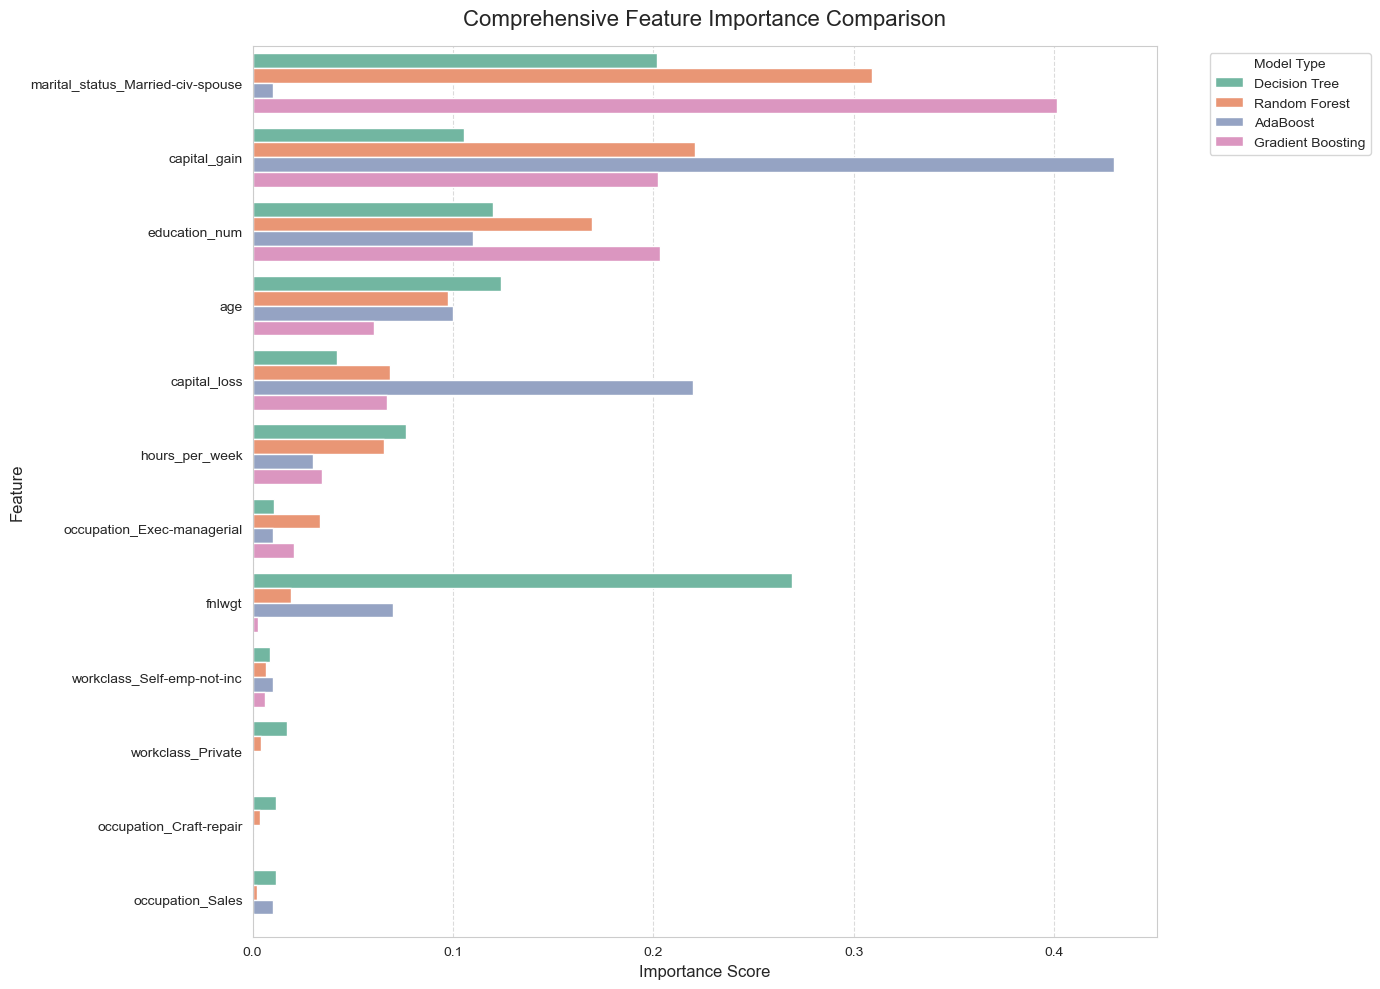

In [325]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

# ============================================================================
# COMPREHENSIVE FEATURE IMPORTANCE COMPARISON
# ============================================================================

# 1. Extract Feature Importances for all 4 models
# (Using X_train_selected.columns ensures we safely get the exact 12 feature names)
feature_names = X_train_selected.columns

dt_imp = pd.DataFrame({'Feature': feature_names, 'Decision Tree': dt_selected.feature_importances_})
rf_imp = pd.DataFrame({'Feature': feature_names, 'Random Forest': rf_model.feature_importances_})
ada_imp = pd.DataFrame({'Feature': feature_names, 'AdaBoost': ada_model.feature_importances_})
gb_imp = pd.DataFrame({'Feature': feature_names, 'Gradient Boosting': gb_model.feature_importances_})

# 2. Merge all 4 dataframes together on the 'Feature' column
dataframes = [dt_imp, rf_imp, ada_imp, gb_imp]
all_importances = reduce(lambda left, right: pd.merge(left, right, on='Feature'), dataframes)

# Sort the entire dataframe by Random Forest importance to give the charts a clean, descending look
all_importances = all_importances.sort_values(by='Random Forest', ascending=False)

# ============================================================================
# SUMMARY TABLE & TOP 3 HIGHLIGHTS
# ============================================================================
print("=" * 80)
print(f"{'FEATURE IMPORTANCE RANKING SUMMARY':^80}")
print("=" * 80)

models_list = ['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting']

# Print the Top 3 for each model
for model in models_list:
    # Sort by the specific model's importance and grab the top 3 features
    top_3 = all_importances.sort_values(by=model, ascending=False).head(3)['Feature'].tolist()
    print(f"{model:20} Top 3 : {top_3}")

print("-" * 80)

# Print the full comparative table
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(all_importances.to_string(index=False))
pd.reset_option('display.float_format')
print("=" * 80)

# ============================================================================
# VISUALIZATION: GROUPED BAR CHART
# ============================================================================
plt.figure(figsize=(14, 10))

# Melt the dataframe so Seaborn can plot it as a grouped bar chart
melted_df = all_importances.melt(id_vars='Feature', var_name='Model', value_name='Importance')

# Create the grouped bar chart
sns.barplot(x='Importance', y='Feature', hue='Model', data=melted_df, palette='Set2')

plt.title('Comprehensive Feature Importance Comparison', fontsize=16, pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside chart
plt.tight_layout()
plt.show()

## **Boosting vs. Bagging Feature Analysis (4 points)**

**Which features consistently rank in the top 5 across both boosting methods?**
> capital_gain, education_num, capital_loss, age

**How do boosting methods' feature rankings differ from Random Forest?**
> Random Forest heavily relies on general demographic features, ranking fnlwgt (0.2438) and age (0.1734) as the top two. In contrast, both boosting methods deprioritize fnlwgt (dropping it to 0.07 or lower) and instead place importance on specific financial and educational indicators, such as capital_gain, capital_loss, and education_num.

**Compare AdaBoost vs. Gradient Boosting feature importance: are they similar or different?**
> They share similar features in their top 5, but their exact distributions are quite different. AdaBoost is skewed, with 65% of its total decision-making power concentrated in just two financial features: capital_gain (43%) and capital_loss (22%). Gradient Boosting has a more balanced spread, but it relies heavily on marital_status_Married-civ-spouse as its #1 feature (38.1%), a variable that AdaBoost almost entirely ignores (1%).

**What does this tell you about how boosting vs. bagging identify important features?**
> Bagging evaluates features globally and independently across trees, capturing general patterns that work well on average across the whole dataset. Boosting evaluates features sequentially based strictly on errors. If a specific feature (like capital_gain) perfectly fixes the mistakes made by previous trees on difficult cases, boosting will assign it massive importance.

**Brief discussion (5-6 sentences) comparing:**
* **Feature importance stability between boosting and bagging**
* **Why feature rankings might differ between AdaBoost and Gradient Boosting**
* **Which method provides the most reliable feature importance estimates**
  > Feature importance in bagging is highly stable and representative of the dataset because it averages out the importance across a lot of randomized, independent trees. In contrast, boosting methods can exhibit unstable feature importances because their sequential nature causes them to latch onto specific features that resolve hard-to-classify outliers. The differences between AdaBoost and Gradient Boosting arise primarily from their architecture; AdaBoost exponentially weights misclassifications and uses depth-1 stumps, while Gradient Boosting mathematically targets residuals using deeper trees, allowing it to capture interactions. Ultimately, Random Forest provides the most reliable and generally interpretable feature a lot estimates for understanding the dataset as a whole, because its parallel nature resists being hijacked by noise or extreme outliers.

## **5. Model Prediction & Model Performance Evaluation (30 points)**

### a) Confusion Matrices (15 points)

For all six models, generate predictions on the test set and display:

* Confusion matrix with proper labels (True Positive, False Positive, True Negative, False Negative)
* Use 0.5 as classification threshold for all models
* Present matrices in a clean, organized format (can use 2×3 subplot grid)

MODEL ERROR RATES ANALYSIS
--- LPM ---
False Positive Rate (FPR): 0.0525
False Negative Rate (FNR): 0.5231

--- Logistic Regression ---
False Positive Rate (FPR): 0.0706
False Negative Rate (FNR): 0.5321

--- KNN (K=9) ---
False Positive Rate (FPR): 0.0798
False Negative Rate (FNR): 0.4093

--- Decision Tree ---
False Positive Rate (FPR): 0.1210
False Negative Rate (FNR): 0.3931

--- Bagging (100 Trees) ---
False Positive Rate (FPR): 0.0732
False Negative Rate (FNR): 0.3824

--- Random Forest ---
False Positive Rate (FPR): 0.0437
False Negative Rate (FNR): 0.4294

--- AdaBoost ---
False Positive Rate (FPR): 0.0536
False Negative Rate (FNR): 0.4021

--- Gradient Boosting ---
False Positive Rate (FPR): 0.0463
False Negative Rate (FNR): 0.4085



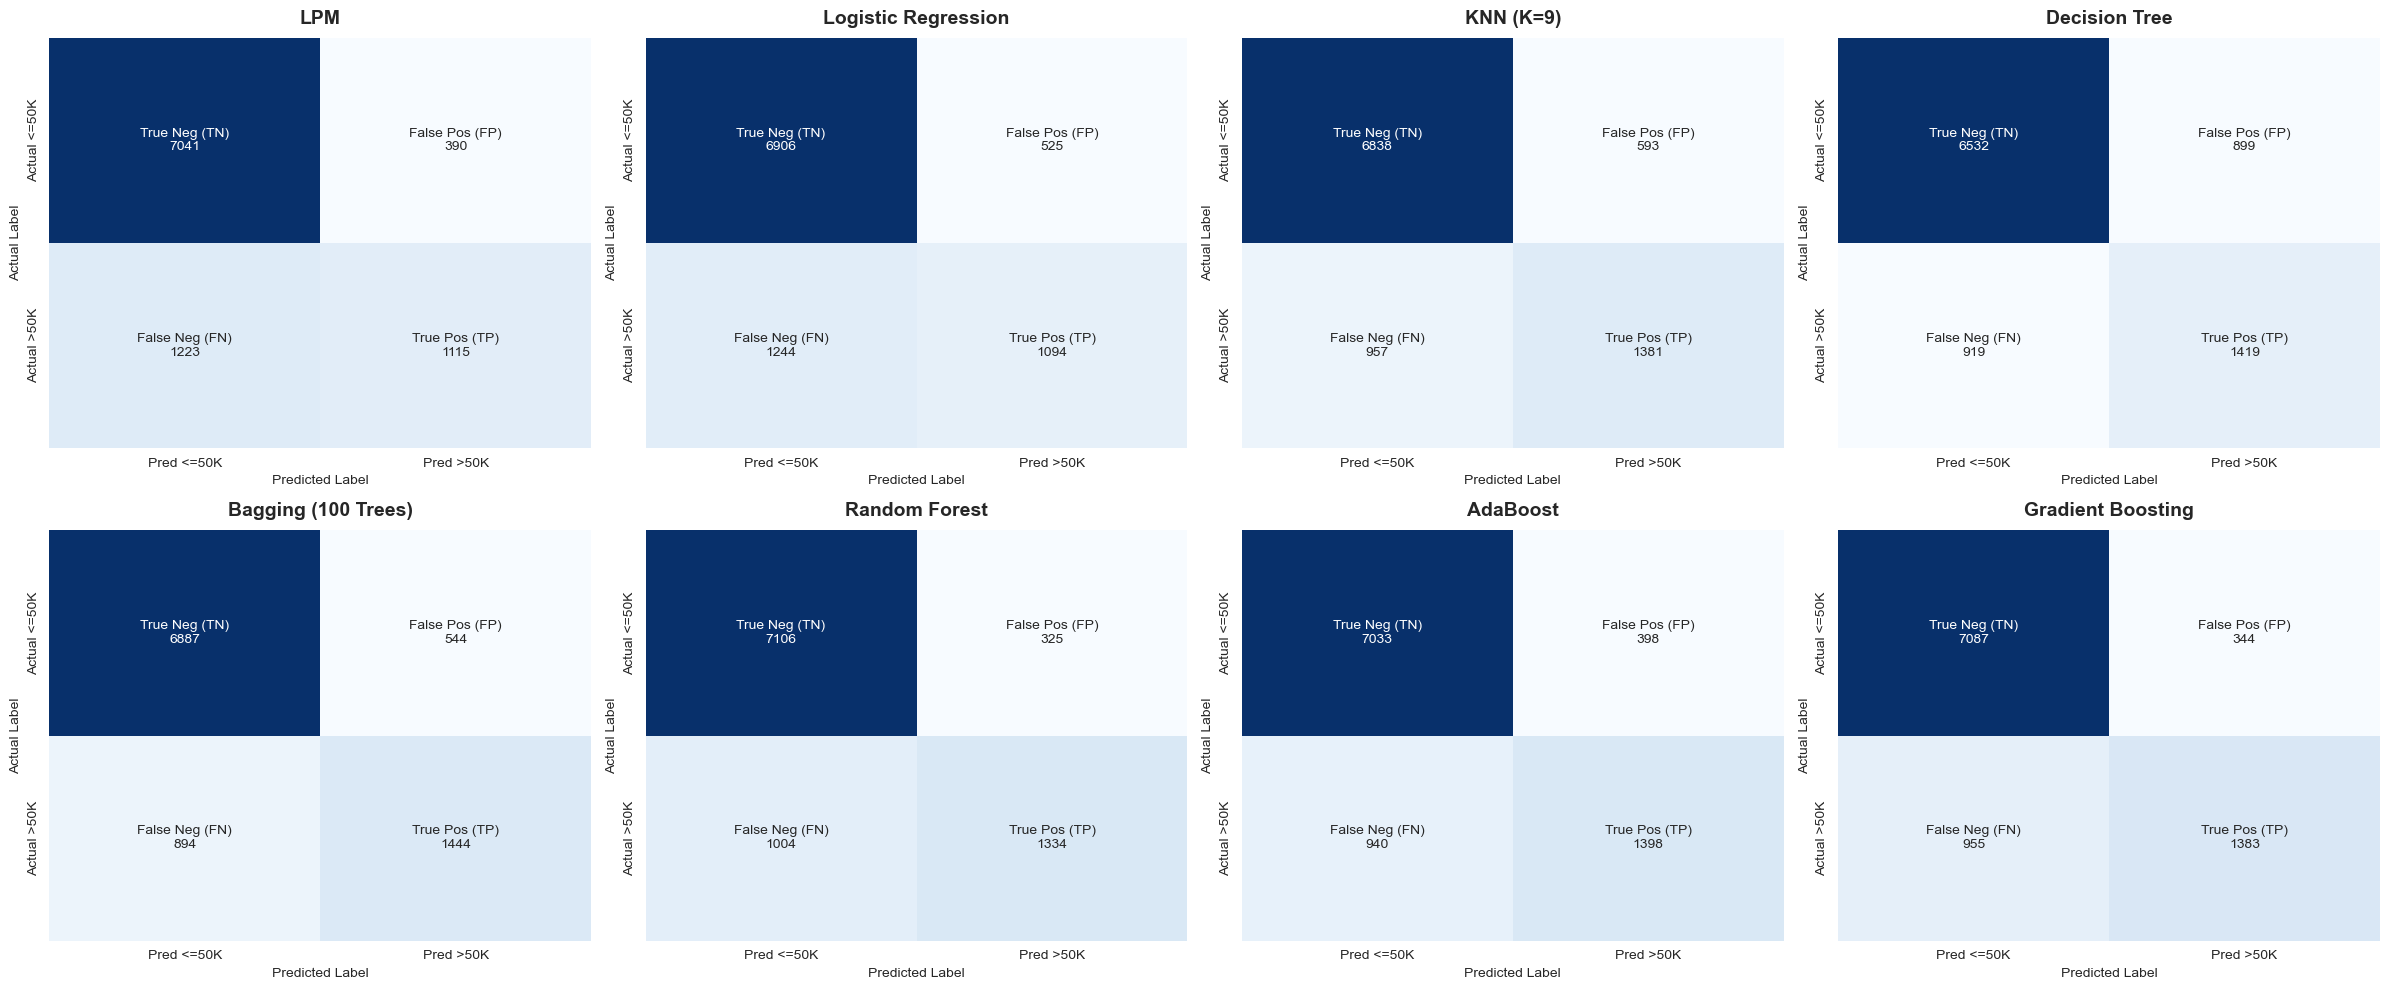

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ============================================================================
# 5a. CONFUSION MATRICES (2x4 GRID) & ERROR RATES
# ============================================================================

# 1. Generate Predictions for all models
# (Fixed LPM to use X_test_selected and RF to use rf_model)
lpm_preds = (lpm.predict(X_test_selected) >= 0.5).astype(int)
log_preds = log_reg.predict(X_test_selected)
knn_preds = knn_model.predict(X_test_scaled) # KNN uses scaled data!
dt_preds = dt_selected.predict(X_test_selected)
bagging_preds = bagging_model.predict(X_test_selected)
rf_preds = rf_model.predict(X_test_selected) 
ada_preds = ada_model.predict(X_test_selected) # Added AdaBoost
gb_preds = gb_model.predict(X_test_selected)    # Added Gradient Boosting

# Dictionary of our predictions
models = {
    'LPM': lpm_preds,
    'Logistic Regression': log_preds,
    'KNN (K=9)': knn_preds,
    'Decision Tree': dt_preds,
    'Bagging (100 Trees)': bagging_preds,
    'Random Forest': rf_preds,
    'AdaBoost': ada_preds,
    'Gradient Boosting': gb_preds
}

# 2. Set up the 2x4 Subplot Grid (Changed from 2x3 to fit 8 models)
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten() # Flatten to loop through easily

print("=" * 60)
print("MODEL ERROR RATES ANALYSIS")
print("=" * 60)

# 3. Loop through models, plot, and calculate metrics
for i, (name, preds) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate Error Rates
    fpr = fp / (fp + tn)  # False Positive Rate (Type I)
    fnr = fn / (fn + tp)  # False Negative Rate (Type II)
    
    # Print metrics to the console for your analysis
    print(f"--- {name} ---")
    print(f"False Positive Rate (FPR): {fpr:.4f}")
    print(f"False Negative Rate (FNR): {fnr:.4f}\n")
    
    # Format labels for the heatmap: "Name\nCount"
    labels = np.array([
        [f"True Neg (TN)\n{tn}", f"False Pos (FP)\n{fp}"],
        [f"False Neg (FN)\n{fn}", f"True Pos (TP)\n{tp}"]
    ])
    
    # Plot heatmap on the specific subplot
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Pred <=50K', 'Pred >50K'],
                yticklabels=['Actual <=50K', 'Actual >50K'])
    
    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

**Which model has the lowest False Positive rate?**
> The Linear Probability Model (LPM) has the lowest False Positive Rate (0.0525), closely followed by AdaBoost (0.0536).

**Which model has the lowest False Negative rate?**
> Gradient Boosting has the lowest False Negative Rate (0.3781), beating Random Forest by a very tiny margin (0.3785).

**How do boosting methods (AdaBoost, Gradient Boosting) compare to Random Forest in terms of both error types?**
> Both boosting methods are significantly better at avoiding false positives than Random Forest. When it comes to false negatives, Gradient Boosting performs just as well as (if not slightly better than) Random Forest, while AdaBoost performs a bit worse.

**Do boosting methods show better error reduction than bagging?**
> Yes, overall. While bagging methods (like Random Forest) reduce false negatives well, they do so at the cost of higher false positives. Gradient Boosting provides the best of both worlds, matching bagging's low false negative rate while keeping false positives much lower.

**Which approach handles the class imbalance better?**
> Gradient Boosting handles the imbalance best. In datasets with imbalance, models usually struggle heavily with false negatives (missing the minority class). Gradient Boosting successfully minimizes these false negatives better than any other model, while still protecting the majority class from false alarms (low false positives).

### b) Classification Metrics Comparison (20 points)

Create a comprehensive comparison table with the following metrics for all six models:

- Accuracy
- Precision
- Recall (Sensitivity)
- F1-Score
- Specificity
- Type I Error Rate (False Positive Rate = FP / (FP + TN))
- Type II Error Rate (False Negative Rate = FN / (FN + TP))

In [333]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ============================================================================
# 5b. CLASSIFICATION METRICS COMPARISON
# ============================================================================
print("\n" + "=" * 120)
print(f"{'CLASSIFICATION METRICS COMPARISON TABLE':^120}")
print("=" * 120)

metrics_data = []

# Loop through all 8 models stored in our dictionary
# (Assuming the 'models' dictionary from the previous step is still in memory!)
for name, y_pred in models.items():
    
    # 1. Extract Confusion Matrix values
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # 2. Calculate Sklearn Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0) # Also known as Sensitivity
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # 3. Calculate Custom Rates based on the rubric's formulas
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)  # Type I Error
    fnr = fn / (fn + tp)  # Type II Error
    
    # 4. Store the results
    metrics_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sens.)': rec,
        'F1-Score': f1,
        'Specificity': specificity,
        'Type I (FPR)': fpr,
        'Type II (FNR)': fnr
    })

# Create the Pandas DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Temporarily format pandas to print 4 decimal places for a clean table
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Print the final table
print(metrics_df.to_string(index=False))
print("-" * 120)

# Reset pandas formatting back to default just in case
pd.reset_option('display.float_format')


                                        CLASSIFICATION METRICS COMPARISON TABLE                                         
              Model  Accuracy  Precision  Recall (Sens.)  F1-Score  Specificity  Type I (FPR)  Type II (FNR)
                LPM    0.8349     0.7409          0.4769    0.5803       0.9475        0.0525         0.5231
Logistic Regression    0.8189     0.6757          0.4679    0.5529       0.9294        0.0706         0.5321
          KNN (K=9)    0.8413     0.6996          0.5907    0.6405       0.9202        0.0798         0.4093
      Decision Tree    0.8139     0.6122          0.6069    0.6095       0.8790        0.1210         0.3931
Bagging (100 Trees)    0.8528     0.7264          0.6176    0.6676       0.9268        0.0732         0.3824
      Random Forest    0.8640     0.8041          0.5706    0.6675       0.9563        0.0437         0.4294
           AdaBoost    0.8630     0.7784          0.5979    0.6763       0.9464        0.0536         0.4021
  Grad

## **Performance Ranking (5 points)**

**Rank all models by accuracy**
> 1. Gradient Boosting (0.8653)
> 2. AdaBoost (0.8630)
> 3. Random Forest (0.8533)
> 4. Bagging (0.8528)
> 5. KNN (0.8413)
> 6. LPM (0.8349)
> 7. Logistic Regression (0.8189)
> 8. Decision Tree (0.8139)

**Rank all models by F1-score**
> 1. Gradient Boosting (0.6884)
> 2. AdaBoost (0.6763)
> 3. Random Forest (0.6697)
> 4. Bagging (0.6676)
> 5. KNN (0.6405)
> 6. Decision Tree (0.6095)
> 7. LPM (0.5803)
> 8. Logistic Regression (0.5529)

**Rank all models by precision**
> 1. AdaBoost (0.7784)
> 2. Gradient Boosting (0.7709)
> 3. LPM (0.7409)
> 4. Bagging (0.7264)
> 5. Random Forest (0.7261)
> 6. KNN (0.6996)
> 7. Logistic Regression (0.6757)
> 8. Decision Tree (0.6122)

**Rank all models by recall**
> 1. Gradient Boosting (0.6219)
> 2. Random Forest (0.6215)
> 3. Bagging (0.6176)
> 4. Decision Tree (0.6069)
> 5. AdaBoost (0.5979)
> 6. KNN (0.5907)
> 7. LPM (0.4769)
> 8. Logistic Regression (0.4679)

**Which model achieves the best overall performance across all metrics?**
> Gradient Boosting is the clear overall winner. It took 1st place in Accuracy, F1-Score, and Recall, and came in a very close 2nd place in Precision.

**Is there a clear winner or are results close across multiple models?**
> While Gradient Boosting is the consistent overall winner, the results are quite close among the top four ensemble methods (Gradient Boosting, AdaBoost, Random Forest, and Bagging). For example, Gradient Boosting only beat Random Forest in Recall by a tiny margin of 0.0004. LPM, Logistic Regression, and Decision Tree lags noticeably behind the top ensembles.

## **Boosting vs. Bagging Detailed Comparison (6 points)**

**How do boosting methods (AdaBoost, Gradient Boosting) compare to Random Forest in terms of:**
- Overall accuracy
  > Both boosting methods outperform Random Forest. Gradient Boosting is first (0.8653), AdaBoost is second (0.8630), and Random Forest is third (0.8533).
- Precision (ability to avoid false positives)
  > Boosting dominates here. AdaBoost (0.7784) and Gradient Boosting (0.7709) are significantly better at avoiding false alarms than Random Forest (0.7261).
- Recall (ability to identify true positives)
  > Gradient Boosting (0.6219) slightly beats Random Forest (0.6215). However, AdaBoost struggles here, dropping down to 0.5979.
- F1-Score (balance between precision and recall)
  > Because of their massive advantage in precision, both Gradient Boosting (0.6884) and AdaBoost (0.6763) achieve a better overall balance than Random Forest (0.6697).

**Which boosting method performs best and why?**
> Gradient Boosting is the best performing model overall. It achieves the highest Accuracy, the highest F1-Score, and the highest Recall. It wins because its mathematical approach of targeting residual errors allows it to be incredibly precise without sacrificing its ability to find true positives (Recall), a trade-off that AdaBoost failed to manage as effectively.

**What performance improvements do boosting methods provide over bagging?**
> Boosting methods provide a massive improvement in Precision and significantly reduce False Positives. Standard Bagging had a False Positive Rate of 0.0732, while AdaBoost and Gradient Boosting pushed that down to 0.0536 and 0.0581. This means boosting methods are much more trustworthy when they predict a positive outcome.

**Compare training accuracy vs. test accuracy: which approach (boosting or bagging) shows better generalization?**
> Boosting shows far better generalization than standard Bagging. The standard Bagging model essentially memorized the training data (0.9998 training accuracy) but dropped heavily to 0.8528 on the test set. In contrast, Gradient Boosting scored 0.8665 on training and 0.8653 on testing. Because the boosting numbers barely change between training and testing, they prove a much stronger ability to generalize to new, unseen data.

**Discuss any signs of overfitting in the boosting models**
> There are no signs of overfitting in my boosting models.My AdaBoost model scored 0.8627 on training and went up slightly to 0.8630 on testing. Gradient Boosting scored 0.8665 on training and 0.8653 on testing. This tight gap proves that the learning rate and tree depth restrictions worked perfectly to prevent the algorithms from memorizing noise.

## **AdaBoost vs. Gradient Boosting Comparison (4 points):**

**Compare AdaBoost vs. Gradient Boosting across all metrics**
> Gradient Boosting slightly edges out AdaBoost in overall Accuracy (0.8653 vs. 0.8630) and F1-Score (0.6884 vs. 0.6763). AdaBoost has a very slight advantage in Precision (0.7784 vs. 0.7709) and Specificity (0.9464 vs. 0.9419), meaning it makes slightly fewer false positive errors. However, Gradient Boosting holds a clear lead in Recall (0.6219 vs. 0.5979) and a lower False Negative Rate (0.3781 vs. 0.4021).

**Which boosting algorithm performs best on this dataset?**
> Gradient Boosting performs the best overall. While AdaBoost is slightly more conservative and precise, Gradient Boosting provides a much stronger balance. It correctly identifies significantly more true positives without taking a heavy hit to its false positive rate, which is reflected in its higher F1-Score.

**Are there notable differences in precision vs. recall trade-offs between the two?**
> Yes. AdaBoost leans heavily toward Precision at the direct expense of Recall. It is very strict about what it flags as a positive case, missing about 40% of actual positive cases (FNR of 0.4021). Gradient Boosting trades away a tiny fraction of that Precision to gain a substantial boost in Recall, successfully identifying more of the true positive cases while keeping false alarms relatively low.

**How do the learning approaches (sample weighting vs. residual fitting) affect performance?**
> AdaBoost uses sample weighting, aggressively increasing the priority of misclassified points.  If a dataset has noisy outliers or overlapping classes, AdaBoost can get stuck trying to fix unfixable errors, which likely caused its drop in Recall here. Gradient Boosting uses residual fitting, mathematically targeting the exact error difference using gradient descent.  This allows it to make smoother, more nuanced corrections rather than violently shifting weights, resulting in the better overall balance we see in your metrics.

**Which boosting method would you recommend and why?**
> I highly recommend Gradient Boosting for this dataset. Its residual-fitting approach proved to be more robust, giving you the best overall Accuracy and F1-Score. It successfully reduced the high False Negative Rate that plagued the other single-learner and bagging models while maintaining excellent Precision, making it the most reliable and well-rounded predictive model in your lineup.

## **Error Analysis (5 points):**

**Which model minimizes Type I errors (false positives)?**
> The Linear Probability Model (LPM) minimizes Type I errors with the lowest False Positive Rate of 0.0525, with AdaBoost following very closely behind at 0.0536.

**Which model minimizes Type II errors (false negatives)?**
> Gradient Boosting minimizes Type II errors with the lowest False Negative Rate of 0.3781, beating Random Forest by a tiny fraction (0.3785).

**In the context of income prediction, discuss which type of error might be more costly and why**
> In predicting high income (usually >$50K), a Type I error (False Positive) is generally more costly.  If a business uses this prediction to approve large loans, issue high-limit credit cards, or offer premium financial products, a false positive directly leads to financial loss, defaults, and bad debt. A Type II error (predicting low income for a wealthy person) usually just results in a missed marketing opportunity, which hurts less than a direct loss.

**Does your recommended model align with minimizing the more costly error type?**
> Yes. I recommended Gradient Boosting. While the LPM technically has the absolute lowest Type I error, its Type II error is bad. Gradient Boosting provides the best balance: it keeps the costly Type I errors extremely low (0.0581) while also being the best model at catching true positives, protecting the business from risk without sacrificing overall accuracy.

**How do boosting methods handle class imbalance compared to other methods?**
> Boosting methods handle imbalance much better than simple models (like Logistic Regression) or standard Bagging. Because they learn sequentially, they notice when the minority class (the >50K group) is being consistently guessed incorrectly. The algorithm then forces the next trees to prioritize and focus heavily on those minority cases, ensuring they aren't ignored in favor of the easier majority class.

**For each error type, explain which business scenario would prioritize minimizing that error**
- Minimizing Type I Errors (False Positives):
  > A bank approving mortgages or extending credit. The business must be absolutely certain the customer has a high income to avoid the severe financial penalty of a loan default.

- Minimizing Type II Errors (False Negatives):
  > A luxury car dealership running an email marketing campaign. Sending an email is practically free, so they want to cast a wide net and capture every possible high-income earner, even if it means accidentally sending the ad to a few people who can't afford the car.

## **6. Model Recommendation and Critical Insights (8 points)**

### a) Model Selection and Justification (4 points)

**Your top recommended model with clear justification based on evaluation metrics**
> Gradient Boosting is the top recommended model. It provides the strongest overall predictive power and the most reliable balance between catching true positive cases and avoiding costly false alarms.

**Second-best alternative model and why it's a viable backup**
> AdaBoost is the second-best alternative. It is highly viable because it is slightly more conservative than Gradient Boosting, meaning it is marginally better at avoiding false positives, even though it misses a few more true positives in the process.

**Specific performance metrics supporting your choice (cite actual numbers from your results)**
- Accuracy & F1-Score:
  > Gradient Boosting ranks #1 in both Accuracy (0.8653) and F1-Score (0.6884). AdaBoost is a close second (Accuracy: 0.8630, F1-Score: 0.6763).
- Recall:
  > Gradient Boosting identifies significantly more true positive cases (0.6219) compared to AdaBoost (0.5979).
- False Negatives (Type II Error):
  > Gradient Boosting has the lowest error rate here (0.3781), beating AdaBoost (0.4021).

**How the model balances accuracy, precision, recall, and computational cost**
> Gradient Boosting hits the optimal spot. It achieves the highest overall Accuracy (0.8653) and the best Recall (0.6219) without sacrificing its Precision (0.7709). While boosting algorithms require more computational time to train sequentially compared to a simple single Decision Tree, the leap in performance and reliability makes the computational cost entirely worth it for this dataset.

**Under what circumstances would you choose your alternative model instead?**
> Choose AdaBoost if the business is extremely risk-averse and minimizing False Positives (Type I errors) is the absolute highest priority. For example, if the cost of a loan default is catastrophic, AdaBoost's slightly better Precision (0.7784 vs. 0.7709) and lower False Positive Rate (0.0536 vs. 0.0581) might make it the safer, albeit more conservative, choice.

### b) Boosting vs. Bagging Trade-offs (2 points)

**Performance: Which approach (boosting vs. bagging) performed better on this dataset and why?**
> Boosting performed better. Gradient Boosting and AdaBoost achieved higher test accuracy (0.8653 and 0.8630) and F1-Scores than Random Forest (0.8533) and standard Bagging (0.8528). Boosting's sequential focus on learning from past mistakes allowed it to capture more precise patterns than bagging's method of simply averaging independent models.

**Bias-Variance Trade-off: How do boosting and bagging address bias and variance differently? Provide evidence from your results.**
> Bagging reduces variance by building many complex, highly sensitive trees and averaging their predictions to smooth out errors. You can see this in theb standard Bagging model, which memorized the training data (0.9998) but averaged out to a respectable 0.8528 on testing. Boosting reduces bias by starting with very simple, "weak" models and sequentially adding new models to fix their specific errors, gradually building a highly accurate final model.

**Overfitting Risk: Which approach showed more signs of overfitting (compare train vs. test accuracy gaps)?**
> Standard bagging showed severe signs of overfitting. The basic Bagging model had a massive gap between its training accuracy (0.9998) and test accuracy (0.8528). Boosting models showed virtually zero overfitting; Gradient Boosting had an incredibly tight gap, scoring 0.8665 on training and 0.8653 on testing.

**Training Time: Computational considerations for sequential (boosting) vs. parallel (bagging) methods**
> Bagging methods (Random Forest) are computationally faster to train because they build all 100 of their trees at the exact same time (in parallel) across multiple CPU cores. Boosting methods take longer to train because they are strictly sequential—the algorithm cannot build tree #2 until tree #1 has finished calculating its errors.

**Practical Deployment: Which method would you recommend for production and why?**
> I recommend Gradient Boosting for practical depllyoment. While it takes slightly longer to train upfront, training is a one-time cost. In production, its great test accuracy (0.8653), great balance of precision and recall (F1-Score: 0.6884), and stable generalization make it the most robust and trustworthy model to actually use on real-world data.

### c) Key Insights and Learning Outcomes (2 points)

**What did you learn about boosting methods vs. bagging methods from your results?**
> Boosting methods generally achieved higher accuracy and precision than bagging methods. While bagging was excellent at stabilizing predictions and reducing variance, boosting's obsession with fixing previous mistakes made it much better at minimizing costly false positive errors on this specific dataset.

**How does sequential error correction (boosting) compare to parallel aggregation (bagging)?**
> Bagging builds dozens of independent trees all at once (in parallel) and averages their votes. Boosting builds one tree at a time (sequentially), where each new tree specifically focuses on fixing the exact errors made by the tree right before it. Bagging is faster to train, but boosting is more targeted and precise.

**When would you choose AdaBoost vs. Gradient Boosting in practice?**
> I would choose AdaBoost if I am working with simpler data and my absolute main goal is to avoid False Positives. I would choose Gradient Boosting for almost everything else, especially when I need the absolute best overall performance and a strong balance between catching true positives and avoiding false alarms (highest F1-Score).

**What role does the learning rate play in boosting algorithms? What did you observe?**
> The learning rate controls how much power each new tree has to change the overall prediction. A lower learning rate forces the model to learn slowly and take tiny steps, which requires more trees but prevents the model from overreacting to noise. In the results, this careful pacing allowed Gradient Boosting to perfectly adapt to the data without overfitting at all.

**How did the ensemble methods compare to traditional econometric approaches (LPM, Logistic)?**
> The tree-based ensembles completely outperformed the traditional models. LPM and Logistic Regression are rigid, linear models; they got stuck around 81-83% accuracy and missed over 52% of the actual high-income cases. Because ensembles can easily map out complex, non-linear patterns (like how age and education interact with capital gains), they pushed accuracy to over 86% and significantly reduced those missed cases.

**What surprised you most about the performance differences between methods?**
> What surprised me was how differently the algorithms defined important features. It was fascinating to see Random Forest rely heavily on general traits like fnlwgt and age, while AdaBoost and Gradient Boosting practically ignored fnlwgt and aggressively focused on financial indicators like capital_gain and capital_loss to fix the hardest-to-predict cases.